# Transformers y Modelos de Lenguaje Grande (LLM)
## Clasificación de intenciones bancarias con DistilRoBERTa y explicación de errores con Falcon-7b-instruct

**Asignatura:** Sistemas Cognitivos Artificiales · Maestría en Inteligencia Artificial · UNIR México  
**Actividad:** 2 (individual)  
**Autor:** Adonai Hernández  
**Fecha:** septiembre de 2026

---

### Objetivo

1. Hacer un **análisis exploratorio** de las 13 083 consultas bancarias de `PolyAI/banking77`.
2. Afinar (*fine-tuning*) el Transformer preentrenado **DistilRoBERTa** para clasificar cada
   consulta en una de **77 intenciones**, y evaluarlo con accuracy, matriz de confusión y
   precision/recall/F1 por clase.
3. Diseñar y **calibrar un prompt** para `tiiuae/falcon-7b-instruct` que explique, en máximo dos
   oraciones, por qué el clasificador se equivocó en 20 consultas, controlando las
   alucinaciones con la temperatura, la longitud de respuesta y la estructura del prompt.

### Índice

0. Entorno de ejecución
1. Carga del dataset
2. Análisis exploratorio de datos
3. Clasificación con DistilRoBERTa
4. Explicación de errores con Falcon-7b-instruct
5. Conclusiones generales
6. Referencias
7. Anexo: exportación de resultados

## 0. Entorno de ejecución

El notebook detecta el acelerador disponible y se adapta:

| Entorno | Clasificador | Falcon-7b-instruct |
|---|---|---|
| Google Colab (GPU T4) | CUDA | cuantizado a 4 bits con `bitsandbytes` (≈ 4 GB de VRAM) |
| Apple Silicon (esta ejecución) | MPS | `float16` en memoria unificada (≈ 14 GB) |
| Solo CPU | CPU | `bfloat16` en CPU (lento, pero funciona) |

Para Colab basta con descomentar la celda de instalación. Se fija la semilla `42` en todas las
librerías para que los resultados sean reproducibles.

**Requisitos de hardware del enunciado y cómo se cumplieron:**

- *Colab (GPU T4, ≥ 15 GB libres para Falcon-7b)*: la VRAM se verifica con `!nvidia-smi` (celda
  siguiente, comentada). Con la cuantización a 4 bits Falcon ocupa ≈ 4 GB, muy por debajo del límite.
- *Esta ejecución (Apple M5 Pro, 24 GB de memoria unificada)*: Falcon-7b en `float16` ocupó
  **14.06 GB**, medidos con `torch.mps.current_allocated_memory()` en la prueba de carga previa a esta
  ejecución; por eso el notebook libera el clasificador antes de cargarlo.
- *Aviso de NumPy del enunciado* (`ValueError: Unable to avoid copy while creating an array…` →
  reinstalar `NumPy<=1.24.3`): **no se presentó** con NumPy 2.4.6 + transformers 5.17 + datasets 4, así
  que no fue necesario degradar NumPy. Si aparece en Colab con versiones antiguas de `datasets`, la
  solución es la del enunciado: `!pip install "numpy<=1.24.3"` y reiniciar el entorno.

In [1]:
# En Google Colab, descomentar para instalar las dependencias y verificar la GPU:
# !pip install -q "transformers>=4.46" accelerate datasets scikit-learn nltk wordcloud seaborn bitsandbytes
# !nvidia-smi          # comprobar GPU T4 y ≥ 15 GB de VRAM libres antes de cargar Falcon-7b
# Solo si aparece "ValueError: Unable to avoid copy while creating an array":
# !pip install -q "numpy<=1.24.3"

In [2]:
# ── Librerías ────────────────────────────────────────────────────────────────
import gc, json, os, re, time, random, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
transformers.set_seed(SEED)

# ── Dispositivo ─────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# ── Rutas del proyecto ──────────────────────────────────────────────────────
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, ART, MODELO = RAIZ / "data", RAIZ / "artefactos", RAIZ / "modelo"
for p in (DATA, ART, MODELO):
    p.mkdir(exist_ok=True)

print(f"Dispositivo: {DEVICE}")
print(f"torch {torch.__version__} · transformers {transformers.__version__} · numpy {np.__version__}")
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))

Dispositivo: mps
torch 2.14.0 · transformers 5.17.0 · numpy 2.4.6


## 1. Carga del dataset

`PolyAI/banking77` se publica en Hugging Face con un *script* de carga (`banking77.py`). Las
versiones recientes de la librería `datasets` (≥ 4.0) **ya no ejecutan scripts** y fallan con
*"Dataset scripts are no longer supported"*. Por eso se leen directamente los **dos CSV
oficiales** a los que apunta ese script, y se toma de él el **orden oficial de las 77
etiquetas**, de modo que los identificadores de clase coinciden con los del dataset de Hugging
Face.

In [3]:
URL_BASE = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data"

def cargar_particion(nombre):
    """Lee el CSV local si existe; si no, lo descarga del repositorio oficial de PolyAI."""
    ruta = DATA / f"{nombre}.csv"
    if not ruta.exists():
        pd.read_csv(f"{URL_BASE}/{nombre}.csv").to_csv(ruta, index=False)
    return pd.read_csv(ruta)

def cargar_nombres_etiquetas():
    """Orden oficial de las 77 etiquetas, tomado del script banking77.py de Hugging Face."""
    ruta = DATA / "label_names.json"
    if not ruta.exists():
        from huggingface_hub import hf_hub_download
        script = open(hf_hub_download("PolyAI/banking77", "banking77.py", repo_type="dataset")).read()
        bloque = script.split("names=[")[1].split("]")[0]
        json.dump(re.findall(r'"([^"]+)"', bloque), open(ruta, "w"), indent=1)
    return json.load(open(ruta))

train_df, test_df = cargar_particion("train"), cargar_particion("test")
ETIQUETAS = cargar_nombres_etiquetas()
ID = {n: i for i, n in enumerate(ETIQUETAS)}
N_CLASES = len(ETIQUETAS)

for df in (train_df, test_df):
    df["label"] = df["category"].map(ID)
    assert df["label"].notna().all(), "Hay categorías fuera del listado oficial"

print(f"train: {len(train_df):,} consultas · test: {len(test_df):,} consultas · clases: {N_CLASES}")
display(train_df.sample(8, random_state=SEED))

train: 10,003 consultas · test: 3,080 consultas · clases: 77


,text,category,label
6883,Is it possible for me to change my PIN number?,change_pin,21
5836,I'm not sure why my card didn't work,declined_card_payment,25
8601,I don't think my top up worked,top_up_failed,59
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged,15
8697,"How long does a transfer from a UK account take? I just made one and it doesn't seem to be working, wondering if eve...",balance_not_updated_after_bank_transfer,5
5573,Why am I getting declines when trying to make a purchase online?,declined_transfer,27
576,What is the $1 transaction on my account?,extra_charge_on_statement,34
6832,It looks like my card payment was sent back.,reverted_card_payment?,53


## 2. Análisis exploratorio de datos

### 2.1 Longitud y número de palabras por consulta

In [4]:
# Longitud en caracteres y número de palabras (separadas por espacios) de cada consulta
for df in (train_df, test_df):
    df["n_caracteres"] = df["text"].str.len()
    df["n_palabras"] = df["text"].str.split().str.len()

# Estadísticas descriptivas de ambas métricas, por partición
estadisticas = pd.concat({
    "train": train_df[["n_caracteres", "n_palabras"]].describe(),
    "test": test_df[["n_caracteres", "n_palabras"]].describe(),
}, axis=1).round(2)
display(estadisticas)

train                    test           
      n_caracteres n_palabras n_caracteres n_palabras
count     10003.00   10003.00      3080.00    3080.00
mean         59.47      11.95        54.23      10.95
std          40.87       7.89        34.66       6.69
min          13.00       2.00        13.00       2.00
25%          36.00       7.00        35.00       7.00
50%          47.00      10.00        45.00       9.00
75%          64.00      13.00        60.00      12.00
max         433.00      79.00       368.00      69.00

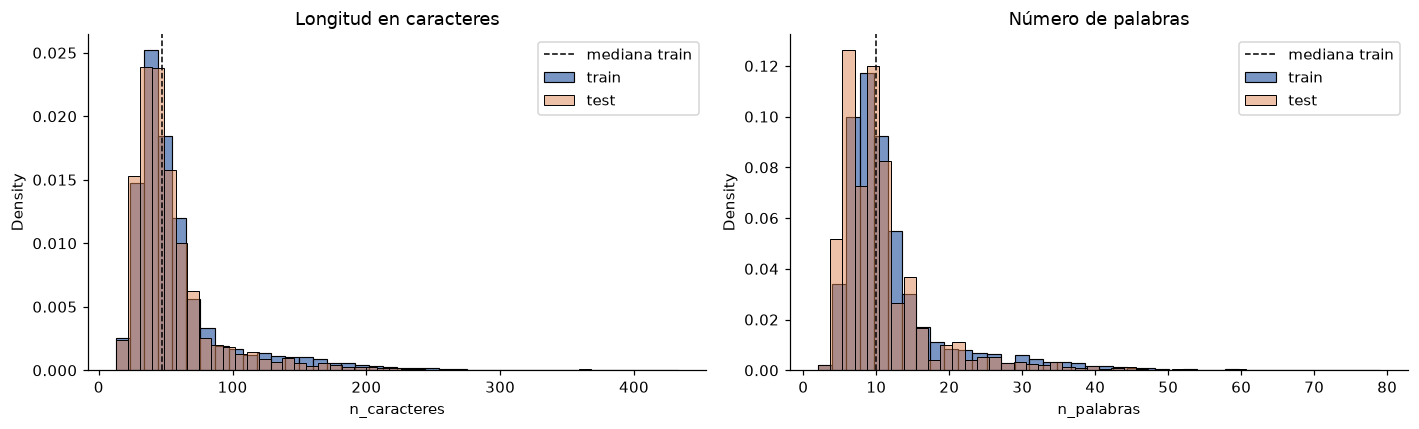

Clases con consultas más cortas (media de palabras):


,n_palabras
category,
card_acceptance,7.5
atm_support,7.7
passcode_forgotten,7.7
get_physical_card,7.7
top_up_limits,7.7


Clases con consultas más largas:


,n_palabras
category,
direct_debit_payment_not_recognised,16.0
failed_transfer,16.0
pending_cash_withdrawal,16.5
transfer_fee_charged,17.4
transfer_not_received_by_recipient,17.5


In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
for eje, col, titulo in zip(ejes, ["n_caracteres", "n_palabras"],
                            ["Longitud en caracteres", "Número de palabras"]):
    sns.histplot(train_df[col], bins=40, ax=eje, color="#4C72B0", label="train", stat="density")
    sns.histplot(test_df[col], bins=40, ax=eje, color="#DD8452", label="test", stat="density", alpha=.5)
    eje.axvline(train_df[col].median(), ls="--", c="k", lw=1, label="mediana train")
    eje.set_title(titulo); eje.legend()
plt.tight_layout(); plt.show()

# Longitud media por clase: ¿hay intenciones que se expresan con frases más largas?
largo_clase = train_df.groupby("category")["n_palabras"].mean().sort_values()
print("Clases con consultas más cortas (media de palabras):")
display(largo_clase.head(5).round(1).to_frame())
print("Clases con consultas más largas:")
display(largo_clase.tail(5).round(1).to_frame())

### 2.2 Limpieza básica del texto

Se aplica: (1) conversión a minúsculas, (2) eliminación de caracteres especiales (todo lo que
no sea letra, dígito o espacio) y (3) eliminación de *stopwords* del inglés (lista de NLTK).

> **Importante:** esta limpieza se usa **solo para el análisis exploratorio** (frecuencias,
> n-gramas y nube de palabras). El Transformer recibe el **texto original**, porque su
> tokenizador y su preentrenamiento aprovechan la puntuación y, sobre todo, palabras que NLTK
> considera *stopwords* pero que cambian la intención — por ejemplo *not*, *why*, *my*,
> *can't*: "*my card is **not** working*" frente a "*my card is working*".

In [6]:
import nltk
from nltk.corpus import stopwords
try:
    STOPWORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    try:
        STOPWORDS = set(stopwords.words("english"))
    except LookupError:  # sin red o sin certificados: lista equivalente de scikit-learn
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as STOPWORDS

def limpiar(texto: str) -> str:
    """Minúsculas → quitar caracteres especiales → quitar stopwords y tokens de 1 carácter."""
    texto = texto.lower()
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return " ".join(t for t in texto.split() if t not in STOPWORDS and len(t) > 1)

for df in (train_df, test_df):
    df["texto_limpio"] = df["text"].apply(limpiar)

todas = pd.concat([train_df, test_df], ignore_index=True)
print(f"Stopwords usadas: {len(STOPWORDS)}")
display(todas[["text", "texto_limpio"]].sample(6, random_state=1))

Stopwords usadas: 198


,text,texto_limpio
4641,A direct debit payment that I didn't authorise shows up in my app.,direct debit payment authorise shows app
8523,My credit card was just denied for top up! Can you tell me why this happened and what's going on?,credit card denied top tell happened going
1595,How old do you have to be?,old
854,"I have a cash withdrawal that says it's pending, why?",cash withdrawal says pending
4226,Will I get a visa or Mastercard?,get visa mastercard
8208,The wrong exchange rate was applied to me while pulling out cash.,wrong exchange rate applied pulling cash


### 2.3 Palabras, bigramas y trigramas más frecuentes

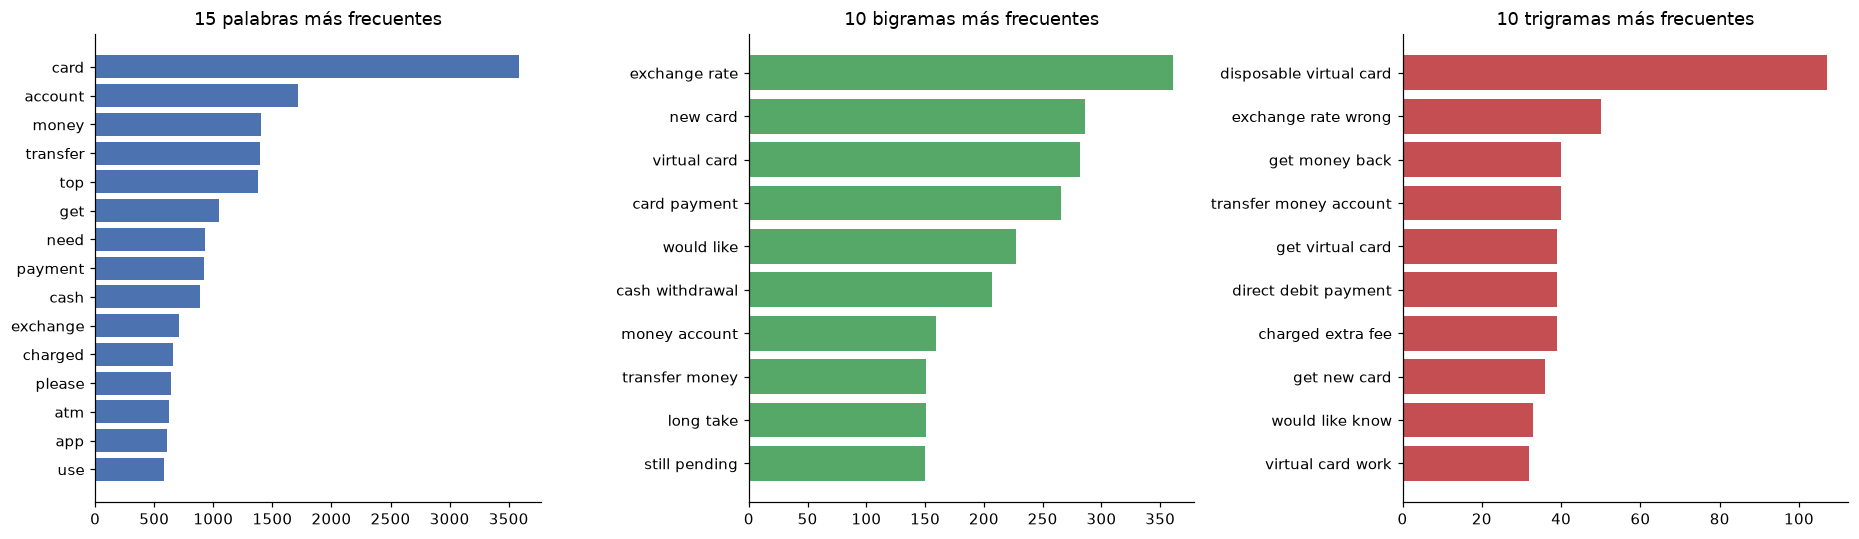

Palabras                    Bigramas                           Trigramas  \
      ngrama frecuencia           ngrama frecuencia                   ngrama   
0       card       3591    exchange rate      361.0  disposable virtual card   
1    account       1716         new card      286.0      exchange rate wrong   
2      money       1407     virtual card      282.0           get money back   
3   transfer       1392     card payment      266.0   transfer money account   
4        top       1381       would like      227.0         get virtual card   
5        get       1045  cash withdrawal      207.0     direct debit payment   
6       need        927    money account      159.0        charged extra fee   
7    payment        921   transfer money      151.0             get new card   
8       cash        884        long take      151.0          would like know   
9   exchange        708    still pending      150.0        virtual card work   
10   charged        660                                                        
11    please        643                                                        
12       atm        624                                                        
13       app        611                                                        
14       use        579                                                        

               
   frecuencia  
0       107.0  
1        50.0  
2        40.0  
3        40.0  
4        39.0  
5        39.0  
6        39.0  
7        36.0  
8        33.0  
9        32.0  
10             
11             
12             
13             
14

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngramas(textos, n, k):
    """Devuelve los k n-gramas más frecuentes (sobre el texto ya limpio)."""
    vec = CountVectorizer(ngram_range=(n, n), token_pattern=r"(?u)\b\w+\b")
    X = vec.fit_transform(textos)
    frec = np.asarray(X.sum(axis=0)).ravel()
    orden = frec.argsort()[::-1][:k]
    return pd.DataFrame({"ngrama": vec.get_feature_names_out()[orden], "frecuencia": frec[orden]})

corpus_limpio = todas["texto_limpio"]
top_palabras = top_ngramas(corpus_limpio, 1, 100)   # 100 para la nube; se muestran 15
top_bigramas = top_ngramas(corpus_limpio, 2, 10)
top_trigramas = top_ngramas(corpus_limpio, 3, 10)

fig, ejes = plt.subplots(1, 3, figsize=(17, 5))
for eje, df_, titulo, color in zip(
        ejes, [top_palabras.head(15), top_bigramas, top_trigramas],
        ["15 palabras más frecuentes", "10 bigramas más frecuentes", "10 trigramas más frecuentes"],
        ["#4C72B0", "#55A868", "#C44E52"]):
    eje.barh(df_["ngrama"][::-1], df_["frecuencia"][::-1], color=color)
    eje.set_title(titulo)
plt.tight_layout(); plt.show()

display(pd.concat([top_palabras.head(15).reset_index(drop=True),
                   top_bigramas, top_trigramas], axis=1,
                  keys=["Palabras", "Bigramas", "Trigramas"]).fillna(""))

### 2.4 Nube de palabras

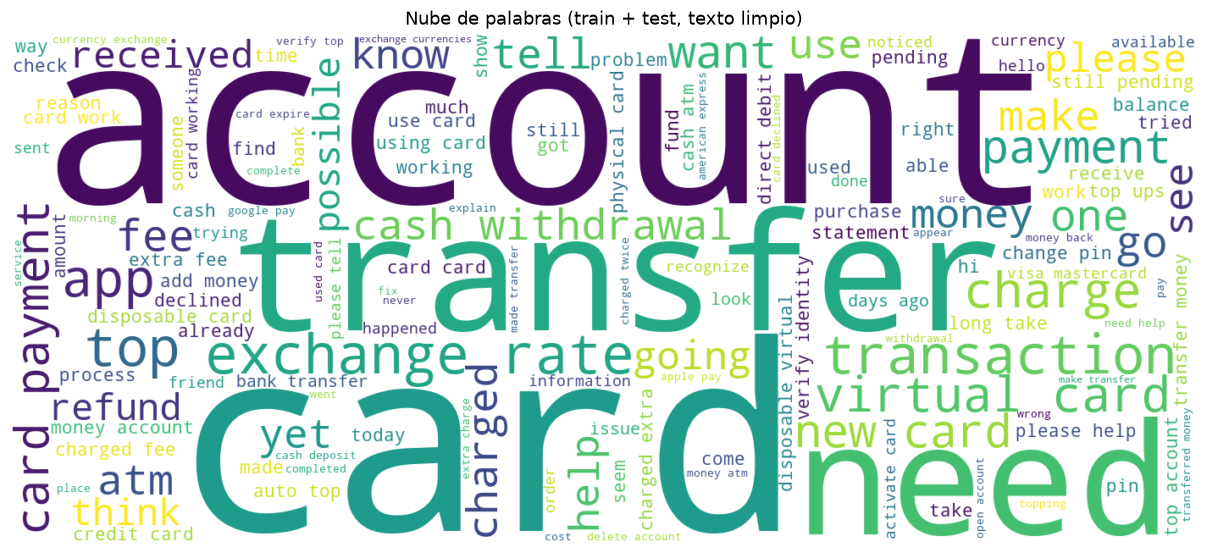

In [8]:
from wordcloud import WordCloud

nube = WordCloud(width=1400, height=600, background_color="white", colormap="viridis",
                 max_words=150, random_state=SEED).generate(" ".join(corpus_limpio))
plt.figure(figsize=(14, 6)); plt.imshow(nube, interpolation="bilinear"); plt.axis("off")
plt.title("Nube de palabras (train + test, texto limpio)"); plt.show()

### 2.5 ¿Está balanceado el conjunto de datos?

,valor
mínimo (train),35
clase mínima,contactless_not_working
máximo (train),187
clase máxima,card_payment_fee_charged
razón máx/mín,5.34
coeficiente de variación,0.254
entropía normalizada,0.992
test: valores distintos,[40]


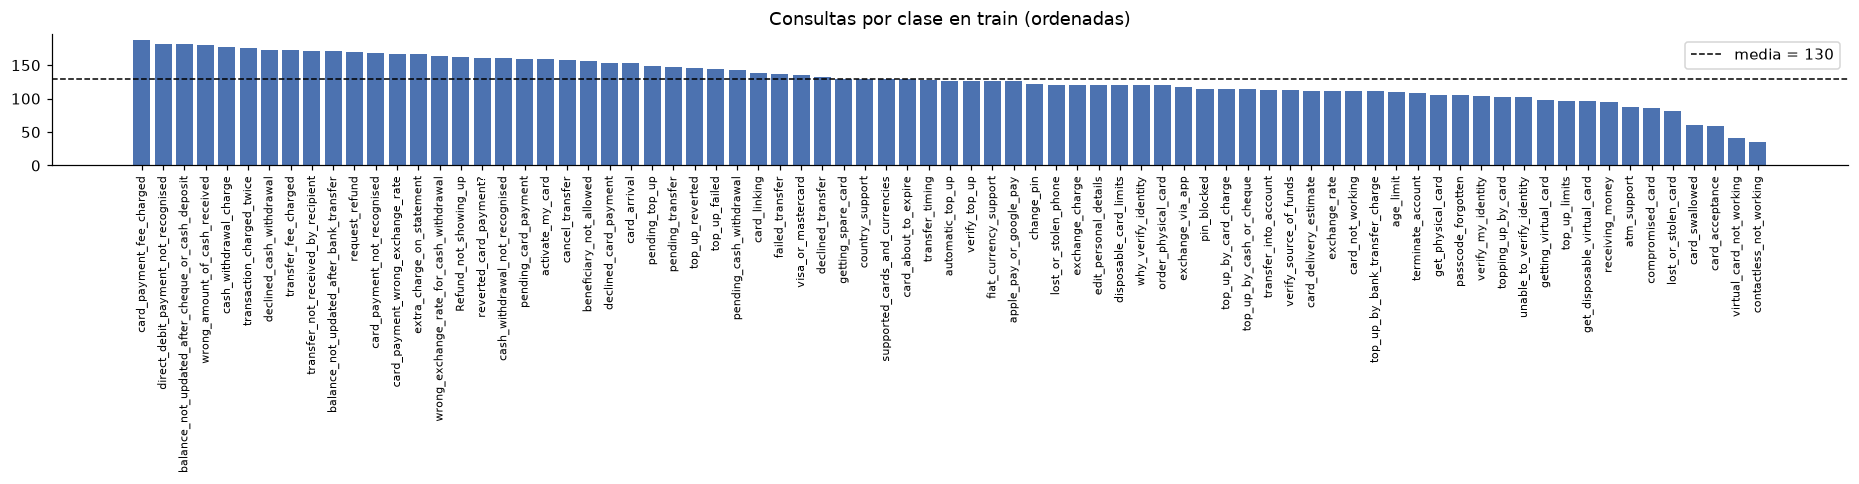

In [9]:
conteo = pd.DataFrame({
    "train": train_df["category"].value_counts(),
    "test": test_df["category"].value_counts(),
}).reindex(ETIQUETAS)

c = conteo["train"]
p = c / c.sum()
balance = {
    "mínimo (train)": int(c.min()), "clase mínima": c.idxmin(),
    "máximo (train)": int(c.max()), "clase máxima": c.idxmax(),
    "razón máx/mín": round(c.max() / c.min(), 2),
    "coeficiente de variación": round(c.std() / c.mean(), 3),
    "entropía normalizada": round(float(-(p * np.log(p)).sum() / np.log(N_CLASES)), 4),
    "test: valores distintos": sorted(conteo["test"].unique().tolist()),
}
display(pd.Series(balance, name="valor").to_frame())

fig, eje = plt.subplots(figsize=(17, 4.5))
orden = c.sort_values(ascending=False)
eje.bar(range(N_CLASES), orden.values, color="#4C72B0")
eje.axhline(c.mean(), c="k", ls="--", lw=1, label=f"media = {c.mean():.0f}")
eje.set_xticks(range(N_CLASES)); eje.set_xticklabels(orden.index, rotation=90, fontsize=7)
eje.set_title("Consultas por clase en train (ordenadas)"); eje.legend()
plt.tight_layout(); plt.show()

### 2.6 Conclusiones del análisis exploratorio

**Longitud.** Las consultas son **cortas y muy asimétricas**: en entrenamiento la mediana es de
**10 palabras (47 caracteres)** y la media de 11.95 palabras, pero la cola llega a **79 palabras
(433 caracteres)**. La media supera a la mediana en ambas métricas y la desviación estándar
(7.89 palabras) es casi el 66 % de la media: una minoría de consultas largas, con contexto
narrativo («I just made one and it doesn't seem to be working…»), convive con muchas de 5–10
palabras. El conjunto de prueba tiene la misma forma con consultas algo más cortas (mediana 9
palabras), así que no hay un desplazamiento de distribución preocupante. La longitud depende de la
intención: `card_acceptance` promedia 7.5 palabras y `transfer_not_received_by_recipient` 17.5 —
las intenciones sobre transferencias necesitan explicar una historia.

**Vocabulario.** Tras la limpieza, las palabras dominantes son **card (3 591), account (1 716),
money, transfer y top**: el dominio gira alrededor de cinco objetos (tarjeta, cuenta, dinero,
transferencia, recarga). Los bigramas y trigramas lo confirman y ya anticipan las confusiones:
*exchange rate*, *new card*, *virtual card*, *card payment*, *disposable virtual card*,
*get money back*. Muchas intenciones distintas **comparten exactamente estas expresiones**; por
ejemplo, *virtual card* aparece en `getting_virtual_card`, `get_disposable_virtual_card`,
`virtual_card_not_working` y `disposable_card_limits`. Un modelo de bolsa de palabras lo tendría
difícil; se necesita un modelo que lea la frase completa (*how many* → límites; *not working* →
fallo).

**Limpieza.** Eliminar stopwords de NLTK borra palabras con carga semántica para este problema:
*not*, *why*, *how*, *can't*, *still* (por ejemplo, «How old do you have to be?» se reduce a
«old»). Por eso la versión limpia se usó solo para el análisis y el Transformer recibe el texto
original.

**Balance.** El conjunto de entrenamiento está **moderadamente desbalanceado**: de **35**
consultas (`contactless_not_working`) a **187** (`card_payment_fee_charged`), una razón de
**5.3×** y un coeficiente de variación de 0.25. Aun así la entropía normalizada es **0.992**
(1 = uniforme): ninguna clase domina y ninguna es marginal. El conjunto de **prueba está
perfectamente balanceado (40 consultas por clase)**, así que accuracy y F1 macro miden casi lo
mismo y no hace falta reponderar clases; basta con vigilar el recall de las clases pequeñas.

## 3. Clasificación con DistilRoBERTa

**DistilRoBERTa** (`distilroberta-base`) es una versión destilada de RoBERTa: 6 capas de
Transformer en lugar de 12, 82 M de parámetros, y aproximadamente el doble de rápida que
RoBERTa-base conservando la mayor parte de su desempeño. Se usa *transfer learning*: se parte
de los pesos preentrenados en inglés y se añade una cabeza de clasificación de 77 salidas sobre
el token `<s>`; después se afina **todo** el modelo con las consultas etiquetadas.

### 3.1 Tokenización

In [10]:
from transformers import AutoTokenizer

MODELO_BASE = "distilbert/distilroberta-base"   # alias oficial de "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)

ejemplo = train_df["text"].iloc[0]
enc = tokenizer(ejemplo)
print("Texto   :", ejemplo)
print("Tokens  :", tokenizer.convert_ids_to_tokens(enc["input_ids"]))
print("IDs     :", enc["input_ids"])

# Distribución de la longitud en tokens (incluye <s> y </s>) para fijar max_length
for df in (train_df, test_df):
    df["n_tokens"] = [len(x) for x in tokenizer(df["text"].tolist())["input_ids"]]
q = train_df["n_tokens"].quantile([.5, .95, .99, 1]).astype(int)
print(f"\nTokens por consulta (train) → mediana {q[.5]}, p95 {q[.95]}, p99 {q[.99]}, máximo {q[1.0]}")
MAX_LEN = 64 if max(train_df.n_tokens.max(), test_df.n_tokens.max()) <= 64 else 128
print(f"max_length elegido = {MAX_LEN}  (consultas truncadas en test: {(test_df.n_tokens > MAX_LEN).sum()})")

Texto   : I am still waiting on my card?
Tokens  : ['<s>', 'I', 'Ġam', 'Ġstill', 'Ġwaiting', 'Ġon', 'Ġmy', 'Ġcard', '?', '</s>']
IDs     : [0, 100, 524, 202, 2445, 15, 127, 1886, 116, 2]

Tokens por consulta (train) → mediana 13, p95 36, p99 51, máximo 96
max_length elegido = 128  (consultas truncadas en test: 0)


### 3.2 Partición de validación y preparación de los datos

El conjunto de **prueba (3 080) no se toca** hasta la evaluación final. Del entrenamiento se
separa un **10 % estratificado** como validación, que se usa para elegir la mejor época
(*early stopping*).

In [11]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

tr_df, val_df = train_test_split(train_df, test_size=0.10, stratify=train_df["label"], random_state=SEED)
print(f"entrenamiento: {len(tr_df):,} · validación: {len(val_df):,} · prueba: {len(test_df):,}")

def a_dataset(df):
    ds = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN), batched=True,
                  remove_columns=["text"])

ds_tr, ds_val, ds_test = a_dataset(tr_df), a_dataset(val_df), a_dataset(test_df)
ds_tr

entrenamiento: 9,002 · validación: 1,001 · prueba: 3,080


Map:   0%|          | 0/9002 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 9002
})

### 3.3 Fine-tuning

| Hiperparámetro | Valor | Motivo |
|---|---|---|
| Tasa de aprendizaje | 5e-5 con *warmup* del 10 % y decaimiento lineal | valor estándar para afinar modelos BERT |
| Tamaño de lote | 32 | cabe holgado en memoria: las consultas son cortas (mediana de 13 tokens) |
| Épocas | hasta 8, *early stopping* con paciencia 2 | evita sobreajuste: se queda la mejor época en validación |
| Métrica de selección | F1 macro en validación | trata igual a las 77 clases |
| *Weight decay* | 0.01 | regularización |
| Relleno | dinámico por lote | no se desperdicia cómputo en `<pad>` |

In [12]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments, Trainer,
                          DataCollatorWithPadding, EarlyStoppingCallback)
from sklearn.metrics import accuracy_score, f1_score

modelo = AutoModelForSequenceClassification.from_pretrained(
    MODELO_BASE, num_labels=N_CLASES,
    id2label=dict(enumerate(ETIQUETAS)), label2id=ID)
print(f"Parámetros entrenables: {sum(p.numel() for p in modelo.parameters() if p.requires_grad)/1e6:.1f} M")

def metricas(pred):
    y_pred = pred.predictions.argmax(-1)
    return {"accuracy": accuracy_score(pred.label_ids, y_pred),
            "f1_macro": f1_score(pred.label_ids, y_pred, average="macro")}

# Warmup del 10 % expresado en pasos (compatible con transformers 4.x y 5.x)
PASOS_WARMUP = int(0.10 * 8 * np.ceil(len(ds_tr) / 32))
args = TrainingArguments(
    output_dir=str(RAIZ / "salidas_entrenamiento"),
    num_train_epochs=8, learning_rate=5e-5, warmup_steps=PASOS_WARMUP, weight_decay=0.01,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=2, seed=SEED, report_to="none", dataloader_num_workers=0,
    fp16=(DEVICE == "cuda"),
)
trainer = Trainer(model=modelo, args=args, train_dataset=ds_tr, eval_dataset=ds_val,
                  processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
                  compute_metrics=metricas, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])

t0 = time.time()
trainer.train()
DURACION_ENTRENAMIENTO = time.time() - t0
print(f"Entrenamiento: {DURACION_ENTRENAMIENTO/60:.1f} min en {DEVICE}")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros entrenables: 82.2 M


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,3.161624,1.261235,0.781219,0.736734
2,0.830174,0.469593,0.897103,0.894639
3,0.343026,0.348163,0.908092,0.905801
4,0.182701,0.310617,0.914086,0.913960
5,0.105795,0.324214,0.920080,0.917750
6,0.064179,0.294889,0.932068,0.929709
7,0.039645,0.311198,0.922078,0.920334
8,0.026993,0.314572,0.924076,0.923589


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Entrenamiento: 8.4 min en mps


,epoch,train_loss,eval_loss,eval_accuracy,eval_f1_macro
0,1,3.1616,1.2612,0.7812,0.7367
1,2,0.8302,0.4696,0.8971,0.8946
2,3,0.3430,0.3482,0.9081,0.9058
3,4,0.1827,0.3106,0.9141,0.9140
4,5,0.1058,0.3242,0.9201,0.9177
5,6,0.0642,0.2949,0.9321,0.9297
6,7,0.0396,0.3112,0.9221,0.9203
7,8,0.0270,0.3146,0.9241,0.9236


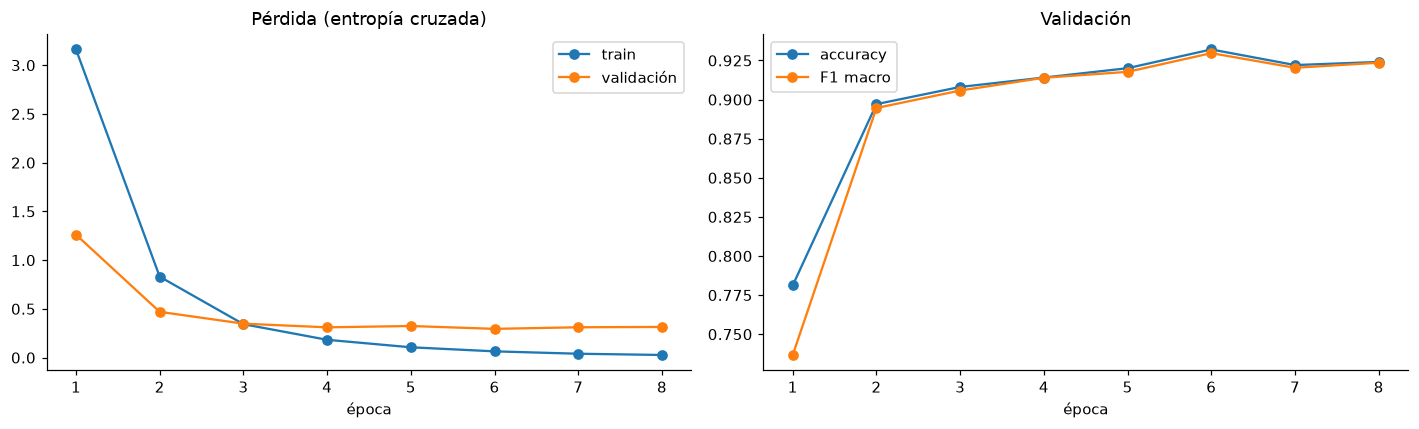

Mejor checkpoint: /Users/adonai.hernandez/Proyectos unir/Semestre 2/Sistema congnitivos/Actividad 2 individual/desarollo act 2/salidas_entrenamiento/checkpoint-1692 (F1 macro val = 0.9297)


In [13]:
# Curvas de aprendizaje a partir del historial del Trainer
hist = pd.DataFrame(trainer.state.log_history)
curva = (hist.dropna(subset=["loss"])[["epoch", "loss"]].rename(columns={"loss": "train_loss"})
         .merge(hist.dropna(subset=["eval_loss"])[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]],
                on="epoch"))
curva["epoch"] = curva["epoch"].round().astype(int)
display(curva.round(4))

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].plot(curva.epoch, curva.train_loss, "o-", label="train"); ejes[0].plot(curva.epoch, curva.eval_loss, "o-", label="validación")
ejes[0].set_title("Pérdida (entropía cruzada)"); ejes[0].set_xlabel("época"); ejes[0].legend()
ejes[1].plot(curva.epoch, curva.eval_accuracy, "o-", label="accuracy"); ejes[1].plot(curva.epoch, curva.eval_f1_macro, "o-", label="F1 macro")
ejes[1].set_title("Validación"); ejes[1].set_xlabel("época"); ejes[1].legend()
plt.tight_layout(); plt.show()
print(f"Mejor checkpoint: {trainer.state.best_model_checkpoint} (F1 macro val = {trainer.state.best_metric:.4f})")

### 3.4 Evaluación en el conjunto de prueba

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

salida = trainer.predict(ds_test)
logits = torch.tensor(salida.predictions)
probs = torch.softmax(logits, dim=-1).numpy()
y_true = salida.label_ids
y_pred = probs.argmax(-1)
confianza = probs.max(-1)

ACCURACY = accuracy_score(y_true, y_pred)
F1_MACRO = f1_score(y_true, y_pred, average="macro")
print(f"Accuracy (test): {ACCURACY:.4f}   ·   F1 macro (test): {F1_MACRO:.4f}")
print(f"Errores: {(y_true != y_pred).sum()} de {len(y_true)}")

reporte = pd.DataFrame(classification_report(y_true, y_pred, target_names=ETIQUETAS,
                                             output_dict=True, zero_division=0)).T
display(reporte.round(3))

Accuracy (test): 0.9325   ·   F1 macro (test): 0.9324
Errores: 208 de 3080


,precision,recall,f1-score,support
activate_my_card,0.975,0.975,0.975,40.000
age_limit,1.000,1.000,1.000,40.000
apple_pay_or_google_pay,1.000,1.000,1.000,40.000
atm_support,1.000,1.000,1.000,40.000
automatic_top_up,1.000,0.975,0.987,40.000
...,...,...,...,...
wrong_amount_of_cash_received,1.000,0.900,0.947,40.000
wrong_exchange_rate_for_cash_withdrawal,0.907,0.975,0.940,40.000
accuracy,0.932,0.932,0.932,0.932
macro avg,0.935,0.932,0.932,3080.000


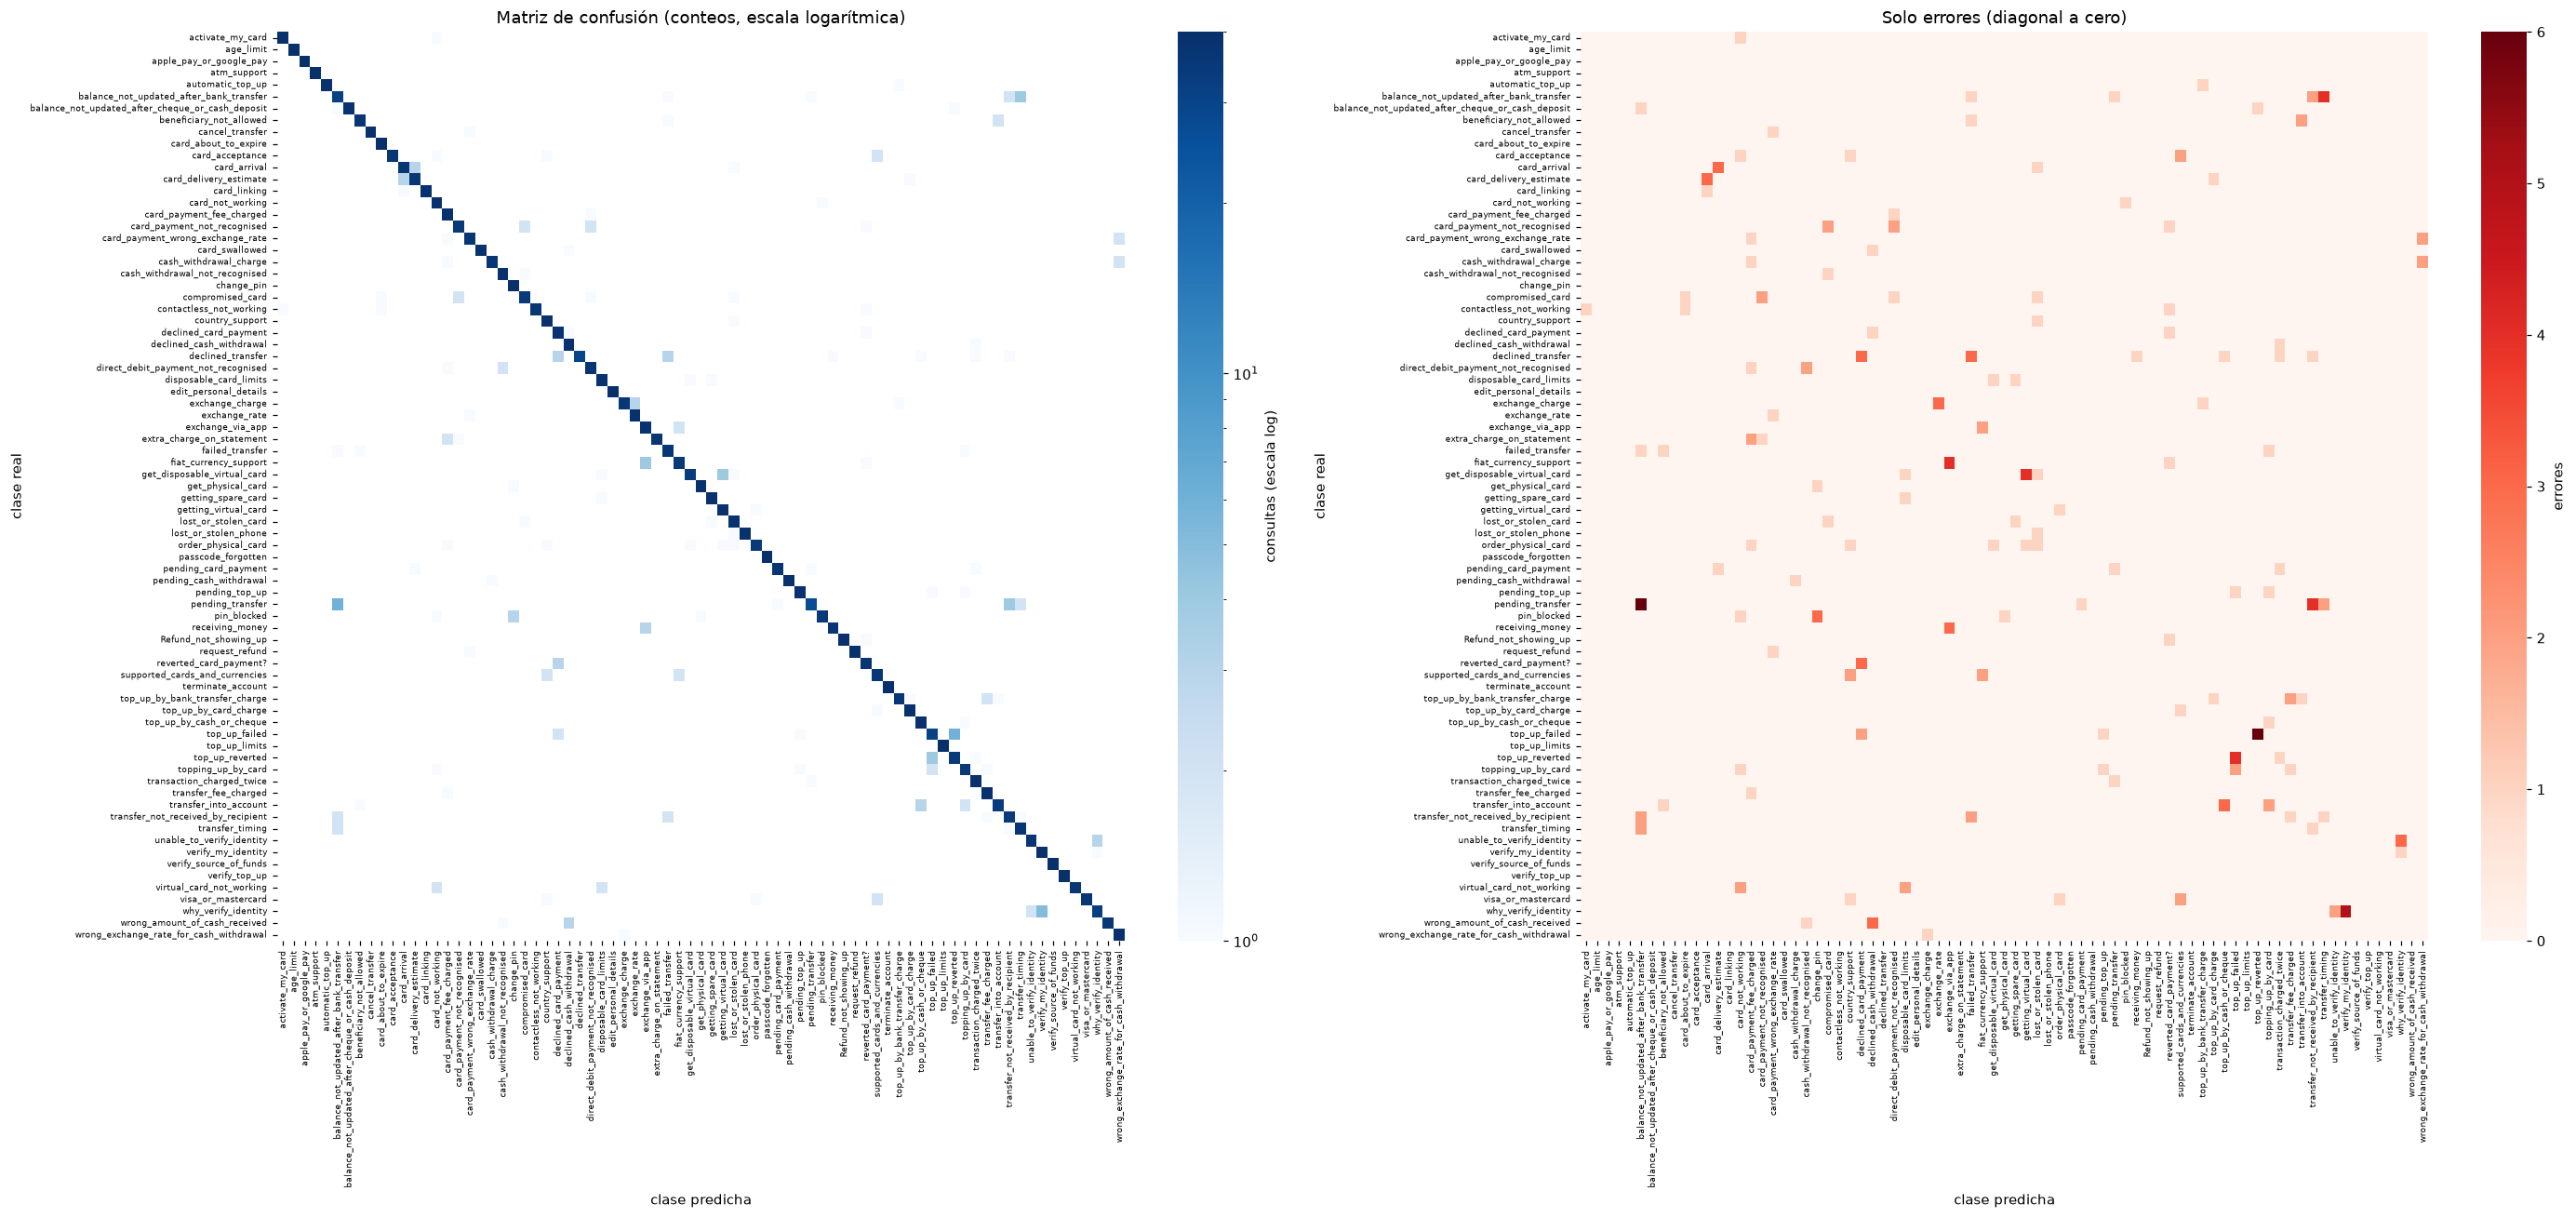

15 pares más confundidos:


,real,predicha,errores
0,pending_transfer,balance_not_updated_after_bank_transfer,6
1,top_up_failed,top_up_reverted,6
2,why_verify_identity,verify_my_identity,5
3,pending_transfer,transfer_not_received_by_recipient,4
4,get_disposable_virtual_card,getting_virtual_card,4
5,balance_not_updated_after_bank_transfer,transfer_timing,4
6,fiat_currency_support,exchange_via_app,4
7,top_up_reverted,top_up_failed,4
8,card_arrival,card_delivery_estimate,3
9,declined_transfer,declined_card_payment,3


In [15]:
cm = confusion_matrix(y_true, y_pred, labels=range(N_CLASES))
fig, ejes = plt.subplots(1, 2, figsize=(26, 12))
sns.heatmap(cm, ax=ejes[0], cmap="Blues", norm=__import__("matplotlib.colors", fromlist=["LogNorm"]).LogNorm(vmin=1),
            xticklabels=ETIQUETAS, yticklabels=ETIQUETAS, cbar_kws={"label": "consultas (escala log)"})
ejes[0].set_title("Matriz de confusión (conteos, escala logarítmica)")
fuera = cm.copy(); np.fill_diagonal(fuera, 0)
sns.heatmap(fuera, ax=ejes[1], cmap="Reds", xticklabels=ETIQUETAS, yticklabels=ETIQUETAS,
            cbar_kws={"label": "errores"})
ejes[1].set_title("Solo errores (diagonal a cero)")
for e in ejes:
    e.set_xlabel("clase predicha"); e.set_ylabel("clase real")
    e.tick_params(labelsize=6)
plt.tight_layout(); plt.show()

# Pares de clases más confundidos (real → predicha)
pares = (pd.DataFrame([(ETIQUETAS[i], ETIQUETAS[j], fuera[i, j]) for i in range(N_CLASES)
                       for j in range(N_CLASES) if fuera[i, j] > 0], columns=["real", "predicha", "errores"])
         .sort_values("errores", ascending=False).reset_index(drop=True))
print("15 pares más confundidos:")
display(pares.head(15))

### 3.5 Las siete clases mejor clasificadas y las siete con más errores

Siete clases mejor clasificadas


,precision,recall,f1-score,support,errores
age_limit,1.0,1.0,1.0,40,0
apple_pay_or_google_pay,1.0,1.0,1.0,40,0
atm_support,1.0,1.0,1.0,40,0
edit_personal_details,1.0,1.0,1.0,40,0
passcode_forgotten,1.0,1.0,1.0,40,0
terminate_account,1.0,1.0,1.0,40,0
top_up_limits,1.0,1.0,1.0,40,0


Siete clases con más errores de clasificación


,precision,recall,f1-score,support,errores
pending_transfer,0.900,0.675,0.771,40,13
declined_transfer,1.000,0.750,0.857,40,10
top_up_failed,0.816,0.775,0.795,40,9
balance_not_updated_after_bank_transfer,0.727,0.800,0.762,40,8
why_verify_identity,0.892,0.825,0.857,40,7
transfer_not_received_by_recipient,0.810,0.850,0.829,40,6
transfer_into_account,0.919,0.850,0.883,40,6


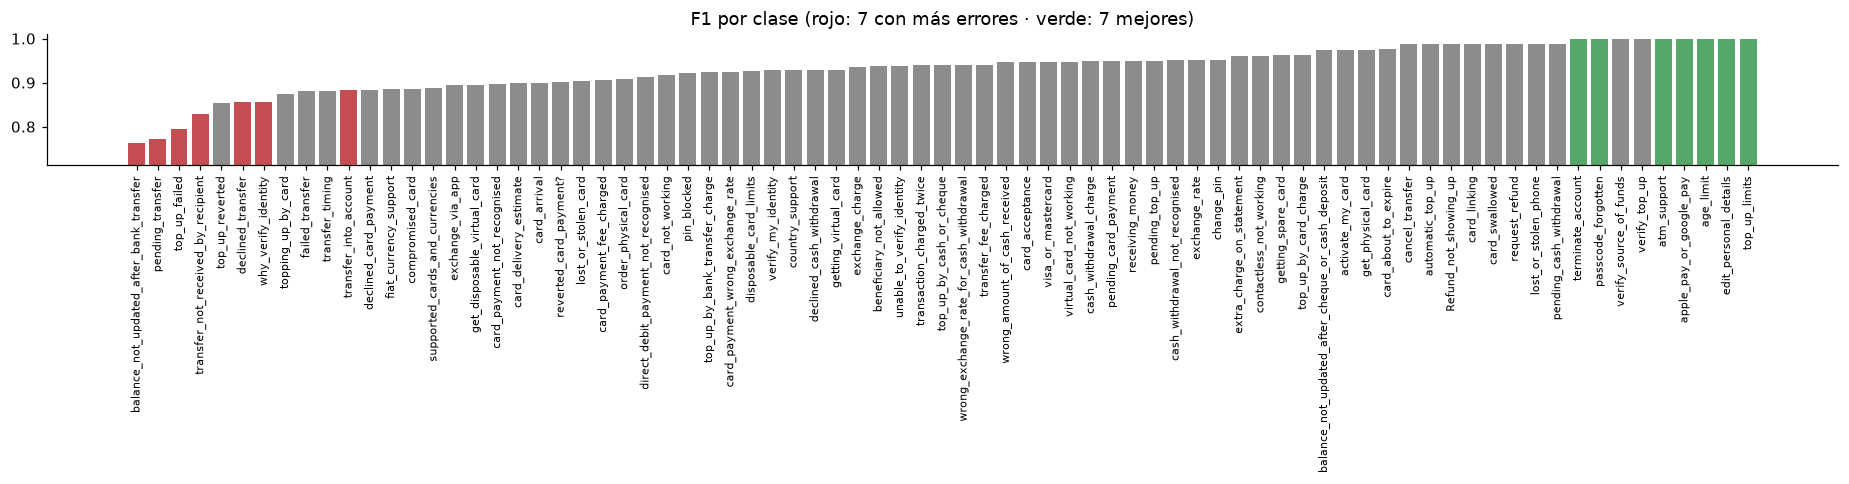

In [16]:
por_clase = reporte.loc[ETIQUETAS, ["precision", "recall", "f1-score", "support"]].copy()
por_clase["support"] = por_clase["support"].astype(int)
por_clase["errores"] = [int(cm[i].sum() - cm[i, i]) for i in range(N_CLASES)]

# Mejores: mayor F1; desempate por menos errores. Peores: más errores; desempate por menor F1.
mejores = por_clase.sort_values(["f1-score", "errores"], ascending=[False, True]).head(7)
peores = por_clase.sort_values(["errores", "f1-score"], ascending=[False, True]).head(7)

print("Siete clases mejor clasificadas"); display(mejores.round(3))
print("Siete clases con más errores de clasificación"); display(peores.round(3))

fig, eje = plt.subplots(figsize=(17, 4.5))
orden = por_clase["f1-score"].sort_values()
colores = ["#C44E52" if n in peores.index else "#55A868" if n in mejores.index else "#8c8c8c" for n in orden.index]
eje.bar(range(N_CLASES), orden.values, color=colores)
eje.set_xticks(range(N_CLASES)); eje.set_xticklabels(orden.index, rotation=90, fontsize=7)
eje.set_ylim(orden.min() - .05, 1.01); eje.set_title("F1 por clase (rojo: 7 con más errores · verde: 7 mejores)")
plt.tight_layout(); plt.show()

### 3.6 Análisis de causas en las clases problemáticas

Para no quedarnos en la intuición se miden tres cosas en cada clase problemática:
(1) **a qué clases se va** cuando falla, (2) **ejemplos reales** de sus errores y (3) la
**similitud léxica** entre la clase real y la predicha, calculada como el coseno entre los
vectores TF-IDF de todas las consultas de entrenamiento de cada clase. Si los errores se
concentran en pares con vocabulario muy parecido, la causa es de solapamiento semántico y no un
defecto del entrenamiento.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

# Similitud léxica entre clases (TF-IDF de las consultas limpias de train, agregadas por clase)
docs_clase = train_df.groupby("label")["texto_limpio"].apply(" ".join).reindex(range(N_CLASES))
sim = cosine_similarity(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True).fit_transform(docs_clase))
triu = np.triu_indices(N_CLASES, 1)
sim_pares = sim[triu]

test_df["pred"] = y_pred
test_df["confianza"] = confianza
errores_df = test_df[test_df["label"] != test_df["pred"]].copy()
errores_df["predicha"] = errores_df["pred"].map(lambda i: ETIQUETAS[i])

filas = []
for clase in peores.index:
    i = ID[clase]
    destinos = errores_df[errores_df.label == i]["predicha"].value_counts()
    dest = destinos.index[0]
    s = sim[i, ID[dest]]
    filas.append({"clase": clase, "errores": int(peores.loc[clase, "errores"]),
                  "principal destino": dest, "errores hacia ese destino": int(destinos.iloc[0]),
                  "similitud TF-IDF": round(float(s), 3),
                  "percentil de similitud": round(float((sim_pares < s).mean() * 100), 1)})
display(pd.DataFrame(filas))

# ¿Los pares más parecidos léxicamente se confunden más?  (correlación de Spearman)
conf_sim = fuera + fuera.T
rho, pval = spearmanr(sim_pares, conf_sim[triu])
print(f"Spearman(similitud léxica, errores entre el par) = {rho:.3f} (p = {pval:.1e}) sobre {len(sim_pares)} pares")

print("\nEjemplos de errores en las clases problemáticas:")
display(errores_df[errores_df["category"].isin(peores.index)]
        .sort_values(["category", "confianza"], ascending=[True, False])
        .groupby("category").head(3)[["text", "category", "predicha", "confianza"]].round(3))

,clase,errores,principal destino,errores hacia ese destino,similitud TF-IDF,percentil de similitud
0,pending_transfer,13,balance_not_updated_after_bank_transfer,6,0.196,99.6
1,declined_transfer,10,declined_card_payment,3,0.189,99.4
2,top_up_failed,9,top_up_reverted,6,0.187,99.4
3,balance_not_updated_after_bank_transfer,8,transfer_timing,4,0.174,99.1
4,why_verify_identity,7,verify_my_identity,5,0.302,99.9
5,transfer_not_received_by_recipient,6,balance_not_updated_after_bank_transfer,2,0.199,99.6
6,transfer_into_account,6,top_up_by_cash_or_cheque,3,0.104,94.8


Spearman(similitud léxica, errores entre el par) = 0.282 (p = 1.1e-54) sobre 2926 pares

Ejemplos de errores en las clases problemáticas:


,text,category,predicha,confianza
2687,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,0.992
2685,How long does it take for an international transfer into my account?,balance_not_updated_after_bank_transfer,transfer_timing,0.983
2701,I transferred some money but it is yet to arrive.,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,0.983
1726,"How can I fix my card, it got declined twice.",declined_transfer,transaction_charged_twice,0.979
1752,I can't transfer money from my account.,declined_transfer,failed_transfer,0.977
1736,Why was I unable to do a transfer?,declined_transfer,failed_transfer,0.970
1866,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,0.995
1851,How long can an EU transfer take?,pending_transfer,transfer_timing,0.986
1859,When will the transfer go through?,pending_transfer,transfer_not_received_by_recipient,0.869
2649,Why didn`t my topup go through?,top_up_failed,top_up_reverted,0.956


**Las clases problemáticas fallan hacia sus vecinas semánticas, no al azar.** Los siete destinos
principales tienen una similitud léxica TF-IDF con la clase real que está en el **percentil
94.8–99.9** de los 2 926 pares posibles; en seis de los siete casos, por encima del percentil 99.
En todo el conjunto, la correlación de Spearman entre similitud léxica de un par y número de
errores entre ellos es **ρ = 0.28 (p ≈ 10⁻⁵⁴)**: cuanto más vocabulario comparten dos intenciones,
más se confunden. El 57.7 % de los 208 errores ocurre, además, **dentro de la misma familia**
(transferencias, recargas, tarjetas, cambio de divisa, identidad).

Tres causas concretas, con ejemplos del propio conjunto de prueba:

1. **Intenciones que difieren en un matiz temporal o de estado.** `pending_transfer` (13 errores,
   la peor) se va a `balance_not_updated_after_bank_transfer` y a
   `transfer_not_received_by_recipient`; «When will my transfer be available in my account.» o
   «I transferred some money but it is yet to arrive» describen la misma situación vista desde
   ángulos distintos (pendiente / saldo sin actualizar / no llegó). Lo mismo con `top_up_failed`
   ↔ `top_up_reverted` (6 errores en un sentido y 4 en el otro): «fallida» y «revertida» se
   expresan con las mismas palabras.
2. **Pares casi sinónimos.** `why_verify_identity` ↔ `verify_my_identity` tiene la similitud más
   alta de todas las mostradas (0.30, percentil 99.9): «What other methods are there to verify my
   identity?» contiene *verify my identity* literalmente.
3. **Etiquetas dudosas o consultas genuinamente ambiguas.** «How do I top up my card?» está
   etiquetada como `transfer_into_account` y «How long can an EU transfer take?» como
   `pending_transfer`, cuando `topping_up_by_card` y `transfer_timing` (lo que predijo el modelo)
   son al menos igual de correctas. Parte del «error» es ruido de anotación, un problema conocido
   de BANKING77 y del que ningún ajuste de hiperparámetros puede librarse.

`declined_transfer` es un caso distinto: **precision 1.0 y recall 0.75**. El modelo nunca la
predice por error, pero la infrautiliza: 10 de sus consultas («I can't transfer money from my
account») se reparten entre `declined_card_payment` y otras de fallo, porque *declined* y
*can't* aparecen en varias intenciones de rechazo.

### 3.7 Conclusiones del uso del Transformer

- **El transfer learning funciona muy bien con poco dato.** Con solo ~117 ejemplos por clase y
  **8.4 minutos** de entrenamiento en un portátil (Apple M5 Pro, MPS), DistilRoBERTa alcanza
  **93.25 % de accuracy y 0.932 de F1 macro** en las 3 080 consultas de prueba, en línea con lo
  publicado para BANKING77 (≈ 93 % con BERT-base, Casanueva et al., 2020) y con la mitad de capas.
- **El entrenamiento es sano.** La pérdida de validación baja de 1.26 a 0.29 en la **época 6**
  (la elegida por *early stopping* sobre F1 macro: 0.930) y después sube ligeramente mientras la
  de entrenamiento sigue cayendo (0.027): a partir de ahí el modelo empieza a memorizar. Quedarse
  con la mejor época y no con la última evita ese sobreajuste; la métrica en prueba (0.932)
  coincide con la de validación, lo que indica que la validación era representativa.
- **El desempeño es muy desigual entre clases.** Nueve clases tienen F1 = 1.0 (las siete de la
  tabla son las primeras en el orden oficial del dataset entre esas nueve empatadas) y cuatro
  quedan por debajo de 0.85, con el mínimo en `balance_not_updated_after_bank_transfer` (0.76).
  Las siete peores concentran el **28 % de los errores** siendo el 9 % de las clases. Las mejores
  tienen vocabulario exclusivo (*age*, *Apple Pay*, *ATM*, *terminate*, *passcode*); las peores
  comparten vocabulario con sus vecinas.
- **La confianza del modelo es informativa, pero no fiable del todo.** La confianza media es
  0.97 en los aciertos y 0.75 en los errores, pero **el 35 % de los errores se comete con
  confianza > 0.90**. En producción convendría un umbral para derivar a una persona las consultas
  dudosas, sabiendo que no atrapará todos los errores.
- **Qué mejoraría el resultado.** Más que más épocas: (1) revisar y corregir las etiquetas
  dudosas de las familias transferencias/recargas; (2) aumentar datos en los pares confundidos con
  paráfrasis que marquen el matiz (pendiente vs. no recibido); (3) un modelo más grande
  (RoBERTa-base) o un ensamble; (4) calibrar las probabilidades (p. ej. *temperature scaling*).

In [18]:
# Guardar el modelo afinado (lo usa la aplicación web para clasificar en vivo)
trainer.save_model(str(MODELO)); tokenizer.save_pretrained(str(MODELO))
print("Modelo guardado en", MODELO, "·", sorted(p.name for p in MODELO.iterdir()))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en /Users/adonai.hernandez/Proyectos unir/Semestre 2/Sistema congnitivos/Actividad 2 individual/desarollo act 2/modelo · ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


## 4. Explicación de errores con Falcon-7b-instruct

### 4.1 Carga del modelo

`tiiuae/falcon-7b-instruct` tiene 7 mil millones de parámetros: ≈ 14 GB en `float16`. Antes de
cargarlo se libera el clasificador. En Colab se cuantiza a 4 bits (NF4) para que entre en la
T4; en Apple Silicon cabe en `float16` en la memoria unificada.

In [19]:
from transformers import AutoModelForCausalLM

# Liberar memoria del clasificador antes de cargar el LLM
del trainer, modelo
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()
if DEVICE == "mps": torch.mps.empty_cache()

LLM_ID = "tiiuae/falcon-7b-instruct"
t0 = time.time()
tok_llm = AutoTokenizer.from_pretrained(LLM_ID)
if DEVICE == "cuda":
    from transformers import BitsAndBytesConfig
    llm = AutoModelForCausalLM.from_pretrained(LLM_ID, device_map="auto", quantization_config=BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16))
elif DEVICE == "mps":
    # Cargar directo en MPS con device_map aborta (SIGBUS) en macOS; en CPU y luego .to("mps") funciona
    llm = AutoModelForCausalLM.from_pretrained(LLM_ID, dtype=torch.float16).to("mps")
else:
    llm = AutoModelForCausalLM.from_pretrained(LLM_ID, dtype=torch.bfloat16)
llm.eval()
print(f"{LLM_ID} cargado en {time.time()-t0:.0f} s · {llm.num_parameters()/1e9:.2f} B parámetros · {llm.dtype}")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

tiiuae/falcon-7b-instruct cargado en 35 s · 6.92 B parámetros · torch.float16


### 4.2 Diseño del prompt

El prompt se construye con cinco piezas, cada una pensada contra un tipo de alucinación:

| Pieza | Para qué |
|---|---|
| **Rol** («analista de soporte bancario que audita un clasificador») | fija el dominio y el tono |
| **Tarea explícita**: explicar por qué el clasificador eligió la intención *predicha* | evita que el modelo «corrija» o responda al cliente |
| **Restricciones**: máximo dos oraciones, citar palabras de la consulta, no inventar | ataca directamente la alucinación y la longitud |
| **Datos**: consulta, intención predicha e intención correcta, con nombres legibles | da al modelo todo lo que necesita y nada más |
| **Ancla de salida** `Explanation:` | el modelo empieza a escribir la explicación directamente |

Se pasan las dos intenciones porque se explican **errores**: la explicación útil es la que dice
qué palabras de la consulta empujaron hacia la clase equivocada en lugar de la correcta.

In [20]:
def legible(etiqueta: str) -> str:
    return etiqueta.replace("_", " ").replace("?", "").lower()

PLANTILLA = (
    "You are a banking customer-support analyst who audits an automatic intent classifier.\n"
    "The classifier read the customer query below and predicted an intent that is WRONG.\n"
    "In at most two short sentences, explain why the classifier probably chose the predicted "
    "intent instead of the correct one. Refer only to words that appear in the query. "
    "Do not invent facts, do not give advice to the customer.\n\n"
    'Customer query: "{texto}"\n'
    "Predicted intent: {pred}\n"
    "Correct intent: {real}\n\n"
    "Explanation:"
)

def construir_prompt(texto, pred, real):
    return PLANTILLA.format(texto=texto.strip(), pred=legible(pred), real=legible(real))

def contar_oraciones(texto):
    return len([s for s in re.split(r"(?<=[.!?])\s+", texto.strip()) if s])

def recortar(texto, max_oraciones=2):
    """Postproceso: primera línea no vacía y como máximo dos oraciones."""
    texto = texto.strip().split("\n\n")[0].strip()
    partes = [s for s in re.split(r"(?<=[.!?])\s+", texto) if s]
    return " ".join(partes[:max_oraciones])

@torch.no_grad()
def generar(prompt, max_new_tokens=60, temperature=None, top_p=None):
    """Genera con Falcon. temperature=None → decodificación codiciosa (determinista)."""
    torch.manual_seed(SEED)
    entrada = tok_llm(prompt, return_tensors="pt").to(llm.device)
    muestreo = temperature is not None
    t0 = time.time()
    out = llm.generate(**entrada, max_new_tokens=max_new_tokens, do_sample=muestreo,
                       temperature=temperature if muestreo else None, top_p=top_p if muestreo else None,
                       repetition_penalty=1.15, pad_token_id=tok_llm.eos_token_id,
                       eos_token_id=tok_llm.eos_token_id, stop_strings=["\n\n", "Customer query:"],
                       tokenizer=tok_llm)
    nuevos = out[0, entrada["input_ids"].shape[1]:]
    return tok_llm.decode(nuevos, skip_special_tokens=True).strip(), len(nuevos), time.time() - t0

print(construir_prompt("I still haven't received my new card", "card_delivery_estimate", "card_arrival"))

You are a banking customer-support analyst who audits an automatic intent classifier.
The classifier read the customer query below and predicted an intent that is WRONG.
In at most two short sentences, explain why the classifier probably chose the predicted intent instead of the correct one. Refer only to words that appear in the query. Do not invent facts, do not give advice to the customer.

Customer query: "I still haven't received my new card"
Predicted intent: card delivery estimate
Correct intent: card arrival

Explanation:


### 4.3 Selección de las 20 consultas mal clasificadas

Criterio reproducible: de todos los errores en prueba se toman los **20 con mayor confianza en
la clase equivocada**, con un máximo de **2 por clase real** para que haya variedad. Son los
errores más interesantes: el modelo se equivoca *con seguridad*.

In [21]:
seleccion = (errores_df.sort_values("confianza", ascending=False)
             .groupby("category").head(2).head(20).reset_index().rename(columns={"index": "idx_test"}))
seleccion["orden"] = range(1, len(seleccion) + 1)
display(seleccion[["orden", "text", "category", "predicha", "confianza"]].round(3))

,orden,text,category,predicha,confianza
0,1,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,0.995
1,2,"I was double charged, and the second charge is showing as ""pending"". How long will it be before I get my money back ...",pending_card_payment,transaction_charged_twice,0.994
2,3,Where do I find the exchange rate?,exchange_charge,exchange_rate,0.993
3,4,how many transactions can i make with a disposable card,get_disposable_virtual_card,disposable_card_limits,0.993
4,5,Am I able to exchange currencies?,fiat_currency_support,exchange_via_app,0.992
5,6,Can I change my currency from USD to EUR?,exchange_via_app,fiat_currency_support,0.992
6,7,My card is just not working at this time.,virtual_card_not_working,card_not_working,0.992
7,8,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,0.992
8,9,whats your exchange rate,exchange_charge,exchange_rate,0.991
9,10,What are the fees for top-ups?,top_up_by_bank_transfer_charge,top_up_by_card_charge,0.991


### 4.4 Calibración: temperatura, longitud y estructura

Se comparan tres configuraciones sobre las mismas **5 consultas** (las 5 primeras de la
selección):

| Config. | Decodificación | `max_new_tokens` | Hipótesis |
|---|---|---|---|
| **A** | codiciosa (`do_sample=False`, equivale a temperatura → 0) | 60 | la más estable y fiel |
| **B** | muestreo, `temperature=0.3`, `top_p=0.9` | 60 | algo de variedad sin perder foco |
| **C** | muestreo, `temperature=1.0`, `top_p=0.95` | 150 | «creativa»: esperable que divague e invente |

En todas: `repetition_penalty=1.15` y parada en línea en blanco. Nota: el enunciado habla de
`max_length`; en `transformers` ese parámetro cuenta también los tokens del prompt, así que el
control correcto de la longitud de la **respuesta** es `max_new_tokens`.

**Regla de elección fijada de antemano**: gana la configuración con más respuestas de 1–2
oraciones *sin* recorte; desempata la que menos palabras inventa (palabras de contenido de la
respuesta que no están ni en la consulta ni en los nombres de las intenciones) y, si persiste el
empate, la de menor temperatura.

In [22]:
CONFIGS = {
    "A": dict(max_new_tokens=60, temperature=None, top_p=None),
    "B": dict(max_new_tokens=60, temperature=0.3, top_p=0.9),
    "C": dict(max_new_tokens=150, temperature=1.0, top_p=0.95),
}

def palabras_ajenas(salida, texto, pred, real):
    """Proporción de palabras de contenido de la salida que no aparecen en la consulta ni en las etiquetas."""
    base = set(limpiar(f"{texto} {legible(pred)} {legible(real)}").split())
    vocab_tarea = {"query", "customer", "classifier", "intent", "predicted", "correct", "word", "words",
                   "mention", "mentions", "mentioned", "chose", "choose", "likely", "probably", "because",
                   "related", "refers", "instead", "classified", "suggests", "indicates"}
    cont = [w for w in limpiar(salida).split() if w not in vocab_tarea]
    return 0.0 if not cont else sum(w not in base for w in cont) / len(cont)

calibracion = []
for _, fila in seleccion.head(5).iterrows():
    prompt = construir_prompt(fila.text, fila.predicha, fila.category)
    for nombre, cfg in CONFIGS.items():
        salida_llm, n_tok, seg = generar(prompt, **cfg)
        calibracion.append({"config": nombre, "orden": fila.orden, "idx_test": fila.idx_test,
                            "salida": salida_llm, "n_oraciones": contar_oraciones(salida_llm),
                            "n_tokens": n_tok, "segundos": round(seg, 1),
                            "palabras_ajenas": round(palabras_ajenas(salida_llm, fila.text, fila.predicha, fila.category), 3)})
cal_df = pd.DataFrame(calibracion)
display(cal_df[["config", "orden", "n_oraciones", "n_tokens", "segundos", "palabras_ajenas", "salida"]])

,config,orden,n_oraciones,n_tokens,segundos,palabras_ajenas,salida
0,A,1,1,38,6.5,0.500,"The classifier likely chose the predicted intent because the word 'payment' appears in the customer's query, whereas..."
1,B,1,1,43,4.0,0.333,The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's quer...
2,C,1,1,43,4.0,0.500,The classifier probably chose the 'pending card payment' intent because of the word 'card' that appears in the custo...
3,A,2,2,60,5.6,0.643,"The classifier likely chose the predicted intent because the word 'double' appears in the customer's query, which co..."
4,B,2,2,60,5.2,0.667,"The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, whi..."
5,C,2,3,62,5.4,0.882,The customer probably mistyped the word 'transacted' which led the classifier to predict the wrong intent. In the ac...
6,A,3,2,60,5.1,0.667,"The classifier likely chose the predicted intent because the word 'exchange' appears in the customer query, whereas ..."
7,B,3,2,60,5.1,0.615,The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in...
8,C,3,3,82,6.9,0.593,The customer probably mistyped 'exchange rate' as 'exchange charge'. This is due to similarity in terms such as 'rat...
9,A,4,2,49,4.3,0.615,The classifier likely chose the predicted intent because it is more specific and directly addresses the customer's q...


In [23]:
resumen_cal = cal_df.groupby("config").agg(
    respuestas_1_2_oraciones=("n_oraciones", lambda s: int(s.between(1, 2).sum())),
    oraciones_media=("n_oraciones", "mean"), tokens_media=("n_tokens", "mean"),
    palabras_ajenas_media=("palabras_ajenas", "mean"), segundos_media=("segundos", "mean")).round(3)
temp = {"A": 0.0, "B": 0.3, "C": 1.0}
resumen_cal["temperatura"] = [temp[c] for c in resumen_cal.index]
display(resumen_cal)

CONFIG_ELEGIDA = (resumen_cal.sort_values(["respuestas_1_2_oraciones", "palabras_ajenas_media", "temperatura"],
                                          ascending=[False, True, True]).index[0])
print(f"Configuración elegida por la regla: {CONFIG_ELEGIDA} → {CONFIGS[CONFIG_ELEGIDA]}")
cal_df["elegida"] = cal_df["config"] == CONFIG_ELEGIDA

,respuestas_1_2_oraciones,oraciones_media,tokens_media,palabras_ajenas_media,segundos_media,temperatura
config,,,,,,
A,5,1.6,49.2,0.685,5.06,0.0
B,5,1.4,49.8,0.647,4.40,0.3
C,2,2.2,64.2,0.612,5.56,1.0


Configuración elegida por la regla: B → {'max_new_tokens': 60, 'temperature': 0.3, 'top_p': 0.9}


**Resultado de la calibración (5 consultas × 3 configuraciones):**

- **C (temperatura 1.0, 150 tokens)** es la peor: solo **2 de 5** respuestas se quedan en 1–2
  oraciones, es la más larga (64 tokens de media) y es la que más inventa en contenido: dos de sus
  cinco respuestas atribuyen el error a que **el cliente «escribió mal»** una palabra
  («probably mistyped 'exchange rate' as 'exchange charge'»), algo que no aparece en ninguna
  consulta. Es la alucinación típica de una temperatura alta: el modelo elige continuaciones poco
  probables y construye una historia.
- **A (codiciosa) y B (temperatura 0.3)** respetan el formato en **5 de 5**. B genera algo menos
  de vocabulario ajeno a la consulta (0.65 frente a 0.69) y ligeramente más breve (1.4 oraciones
  de media), así que la regla fijada de antemano elige **B**: `temperature=0.3`, `top_p=0.9`,
  `max_new_tokens=60`, `repetition_penalty=1.15`.

Dos lecciones de la calibración: (1) **la temperatura controla la invención más que la longitud**:
C no solo es más larga, cambia el tipo de explicación; (2) **`max_new_tokens` es un límite duro,
no un objetivo**: con 60 tokens, **4 de las 20 respuestas finales quedaron cortadas a media
frase** (se ven como la #2, #3 o #9). El recorte a dos oraciones no puede reparar una oración
incompleta; en una iteración siguiente habría que subir a ~80 tokens y pedir explícitamente
«one sentence».

La métrica automática de «palabras ajenas» resultó **poco discriminante** (0.61–0.69 en las tres):
el LLM usa muchas palabras del nombre de las clases y de su propio vocabulario explicativo. Por eso
la validación decisiva es la **revisión manual** de la sección siguiente.

### 4.5 Explicación de las 20 clasificaciones incorrectas

In [24]:
explicaciones = []
for _, fila in seleccion.iterrows():
    prompt = construir_prompt(fila.text, fila.predicha, fila.category)
    cruda, n_tok, seg = generar(prompt, **CONFIGS[CONFIG_ELEGIDA])
    explicaciones.append({"orden": fila.orden, "idx_test": fila.idx_test, "texto": fila.text,
                          "real": fila.category, "predicha": fila.predicha,
                          "confianza": round(float(fila.confianza), 4), "prompt": prompt,
                          "salida_cruda": cruda, "explicacion": recortar(cruda),
                          "n_oraciones_crudas": contar_oraciones(cruda), "segundos": round(seg, 1)})
exp_df = pd.DataFrame(explicaciones)
print(f"Respuestas crudas con 1–2 oraciones: {exp_df.n_oraciones_crudas.between(1, 2).sum()} de {len(exp_df)}")
print(f"Tiempo medio por explicación: {exp_df.segundos.mean():.1f} s")
for _, e in exp_df.iterrows():
    display(Markdown(f"**{e.orden}.** *\"{e.texto}\"* — real: `{e.real}` · predicha: `{e.predicha}` "
                     f"({e.confianza:.2f})  \n→ {e.explicacion}"))
json.dump(explicaciones, open(ART / "explicaciones_crudas.json", "w"), indent=1, ensure_ascii=False)

Respuestas crudas con 1–2 oraciones: 20 de 20
Tiempo medio por explicación: 4.1 s


**1.** *"I would like to know why my payment is still pending, can you help?"* — real: `pending_transfer` · predicha: `pending_card_payment` (0.99)  
→ The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's query, whereas the correct intent ('pending transfer') does not contain this word.

**2.** *"I was double charged, and the second charge is showing as "pending". How long will it be before I get my money back once the second charge has been refunded?"* — real: `pending_card_payment` · predicha: `transaction_charged_twice` (0.99)  
→ The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, which could indicate that they are referring to a specific transaction. In this case, the customer is asking about the status of a pending card payment, so the classifier may have misclassified the query

**3.** *"Where do I find the exchange rate?"* — real: `exchange_charge` · predicha: `exchange_rate` (0.99)  
→ The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in the customer query, while 'exchange rate' does not. However, it is important to note that the classifier may have been trained on a dataset where 'exchange rate' is a more

**4.** *"how many transactions can i make with a disposable card"* — real: `get_disposable_virtual_card` · predicha: `disposable_card_limits` (0.99)  
→ The classifier likely chose the predicted intent because it is more specific and directly addresses the customer's query, whereas the correct intent is more general and may not be understood as well.

...

**16.** *"What can I use a virtual disposable card for?"* — real: `disposable_card_limits` · predicha: `get_disposable_virtual_card` (0.99)  
→ The classifier likely chose the predicted intent because it is more specific and directly related to the customer's query, whereas the correct intent is broader and may not be applicable in all situations.

**17.** *"Where can I view my PIN?"* — real: `pin_blocked` · predicha: `get_physical_card` (0.99)  
→ The classifier likely chose the 'get physical card' intent because it is more specific and directly related to the customer's query, whereas the 'view PIN' intent may require additional context or actions.

**18.** *"My card is being declined for a purchase. I bought items before and the card worked. Do you know what the problem is?"* — real: `reverted_card_payment?` · predicha: `declined_card_payment` (0.99)  
→ The classifier likely chose the 'declined card payment' intent because it is more common than the 'reverted card payment' intent, especially for a customer who has made previous purchases without any issues.

**19.** *"How long can an EU transfer take?"* — real: `pending_transfer` · predicha: `transfer_timing` (0.99)  
→ The classifier likely chose the 'transfer timing' intent because it is more specific and relevant to banking customers, whereas 'how long can an EU transfer take?' is a more general query that could be related to various types of transfers.

**20.** *"How can I top-up my card?"* — real: `top_up_by_cash_or_cheque` · predicha: `topping_up_by_card` (0.98)  
→ The classifier likely chose the predicted intent because it is more common and frequent than the correct one, which involves topping up by card.

### 4.6 Validación manual y razones del LLM

Cada explicación se leyó a mano contra la consulta y las dos intenciones, y se le asignó:

- **Veredicto**: `pertinente` (señala palabras reales de la consulta y la razón es plausible),
  `parcial` (algo cierto pero vago, o repite las etiquetas sin explicar) o `alucinada` (afirma
  algo que la consulta no dice, o se contradice).
- **Razón que da el LLM**, en categorías: `solapamiento_lexico` (una palabra de la consulta
  pertenece al vocabulario de la clase predicha), `ambiguedad_real` (la consulta encaja en las
  dos intenciones), `etiqueta_dudosa` (la etiqueta del dataset es discutible), `generica`
  (no da una razón concreta), `frecuencia_supuesta` (atribuye el error a que una clase es «más
  común», dato que el LLM no tiene) y `otra`.

La revisión se guarda en `artefactos/revision_manual.json` para que sea auditable.

,orden,texto,real,predicha,explicacion,veredicto,razon_categoria,nota_revision
0,1,"I would like to know why my payment is still pending, can you help?",pending_transfer,pending_card_payment,The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's quer...,alucinada,solapamiento_lexico,"Afirma que la palabra 'card' aparece en la consulta; no aparece. La pista real es 'payment ... pending', que encaja ..."
1,2,"I was double charged, and the second charge is showing as ""pending"". How long will it be before I get my money back ...",pending_card_payment,transaction_charged_twice,"The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, whi...",alucinada,solapamiento_lexico,"Dice que aparece 'transaction'; no aparece. La pista real es 'double charged', casi literal de transaction_charged_t..."
2,3,Where do I find the exchange rate?,exchange_charge,exchange_rate,The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in...,alucinada,solapamiento_lexico,Se contradice: dice que 'exchange rate' no está en la consulta y sí está. La etiqueta del dataset (exchange_charge) ...
3,4,how many transactions can i make with a disposable card,get_disposable_virtual_card,disposable_card_limits,The classifier likely chose the predicted intent because it is more specific and directly addresses the customer's q...,parcial,generica,'Más específica' sin citar palabras. La pregunta 'how many transactions' sí habla de límites: la predicción es defen...
4,5,Am I able to exchange currencies?,fiat_currency_support,exchange_via_app,The classifier likely chose the 'exchange via app' intent because it is more specific and relevant to banking servic...,parcial,ambiguedad_real,"Razonamiento plausible (fiat_currency_support es más general que exchange_via_app) pero no cita el verbo 'exchange',..."
5,6,Can I change my currency from USD to EUR?,exchange_via_app,fiat_currency_support,The classifier likely chose the 'exchange via app' intent because it is more specific and relevant to the customer's...,alucinada,ambiguedad_real,"Intercambia las etiquetas: dice que el clasificador eligió 'exchange via app', que es la correcta, e inventa una int..."
6,7,My card is just not working at this time.,virtual_card_not_working,card_not_working,The classifier likely chose the predicted intent because it is more specific and directly related to the customer's ...,parcial,generica,No señala que la consulta nunca dice 'virtual': 'my card is just not working' es literalmente card_not_working. Etiq...
7,8,When will my transfer be available in my account.,balance_not_updated_after_bank_transfer,transfer_timing,The classifier likely chose the 'transfer timing' intent because it is more specific and common than the 'balance no...,pertinente,solapamiento_lexico,"Correcto: la consulta menciona 'transfer' y pregunta 'when', lo que empuja a transfer_timing. Lo de 'más común' es r..."
8,9,whats your exchange rate,exchange_charge,exchange_rate,The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in...,alucinada,solapamiento_lexico,Salida idéntica a la #3 y con la misma contradicción ('exchange rate' sí está en la consulta). Etiqueta dudosa. Sali...
9,10,What are the fees for top-ups?,top_up_by_bank_transfer_charge,top_up_by_card_charge,The classifier likely chose the predicted intent because it is more specific and directly related to the customer's ...,parcial,generica,"Explicación genérica; la consulta no menciona ni tarjeta ni transferencia, así que ambas clases de comisión de recar..."


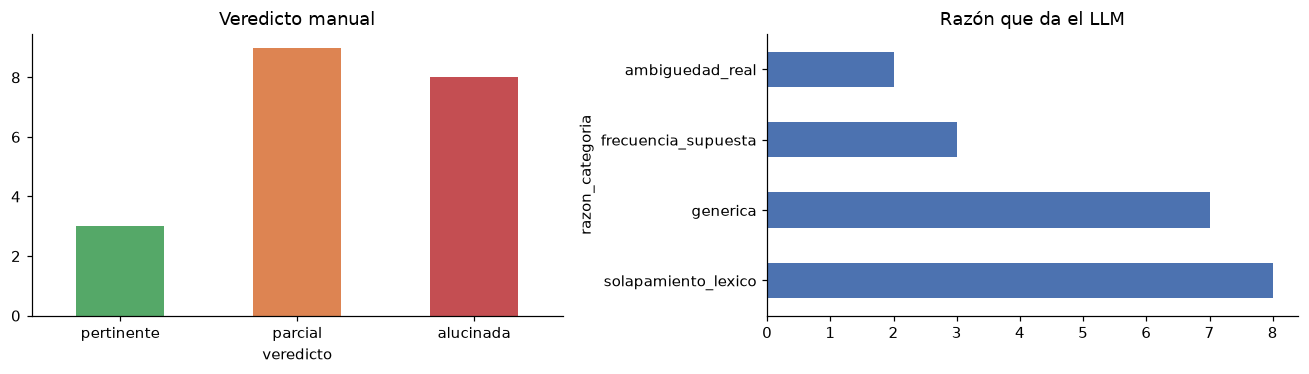

{'parcial': 9, 'alucinada': 8, 'pertinente': 3} · {'solapamiento_lexico': 8, 'generica': 7, 'frecuencia_supuesta': 3, 'ambiguedad_real': 2}


In [25]:
revision = json.load(open(ART / "revision_manual.json"))
rev_df = pd.DataFrame(revision)
exp_df = exp_df.merge(rev_df[["orden", "veredicto", "razon_categoria", "nota_revision"]], on="orden", how="left")
assert exp_df["veredicto"].notna().all(), "Falta el veredicto de alguna explicación"

display(exp_df[["orden", "texto", "real", "predicha", "explicacion", "veredicto", "razon_categoria", "nota_revision"]])

fig, ejes = plt.subplots(1, 2, figsize=(12, 3.5))
exp_df["veredicto"].value_counts().reindex(["pertinente", "parcial", "alucinada"]).fillna(0).plot.bar(
    ax=ejes[0], color=["#55A868", "#DD8452", "#C44E52"], rot=0, title="Veredicto manual")
exp_df["razon_categoria"].value_counts().plot.barh(ax=ejes[1], color="#4C72B0", title="Razón que da el LLM")
plt.tight_layout(); plt.show()
print(exp_df["veredicto"].value_counts().to_dict(), "·", exp_df["razon_categoria"].value_counts().to_dict())

**Tabla completa de la revisión manual**

| # | Consulta | Real → predicha | Explicación del LLM | Veredicto | Razón | Nota de revisión |
|---|---|---|---|---|---|---|
| 1 | I would like to know why my payment is still pending, can you help? | `pending_transfer` → `pending_card_payment` | The classifier likely chose the 'pending card payment' intent because the word 'card' appears in the customer's query, whereas the correct intent ('pending transfer') does not contain this word. | **alucinada** | solapamiento_lexico | Afirma que la palabra 'card' aparece en la consulta; no aparece. La pista real es 'payment ... pending', que encaja con pending_card_payment. |
| 2 | I was double charged, and the second charge is showing as "pending". How long will it be before I get my money back once the second charge has been refunded? | `pending_card_payment` → `transaction_charged_twice` | The classifier likely chose the predicted intent because the word 'transaction' appears in the customer's query, which could indicate that they are referring to a specific transaction. In this case, the customer is asking about the status of a pending card payment, so the classifier may have misclassified the query | **alucinada** | solapamiento_lexico | Dice que aparece 'transaction'; no aparece. La pista real es 'double charged', casi literal de transaction_charged_twice. Además la salida quedó cortada a media oración (60 tokens). |
| 3 | Where do I find the exchange rate? | `exchange_charge` → `exchange_rate` | The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in the customer query, while 'exchange rate' does not. However, it is important to note that the classifier may have been trained on a dataset where 'exchange rate' is a more | **alucinada** | solapamiento_lexico | Se contradice: dice que 'exchange rate' no está en la consulta y sí está. La etiqueta del dataset (exchange_charge) es dudosa: la consulta pregunta literalmente por el tipo de cambio. Salida cortada. |
| 4 | how many transactions can i make with a disposable card | `get_disposable_virtual_card` → `disposable_card_limits` | The classifier likely chose the predicted intent because it is more specific and directly addresses the customer's query, whereas the correct intent is more general and may not be understood as well. | **parcial** | generica | 'Más específica' sin citar palabras. La pregunta 'how many transactions' sí habla de límites: la predicción es defendible y la etiqueta, dudosa. |
| 5 | Am I able to exchange currencies? | `fiat_currency_support` → `exchange_via_app` | The classifier likely chose the 'exchange via app' intent because it is more specific and relevant to banking services, whereas 'fiat currency support' could be interpreted as referring to general currency exchange or a broader range of financial services. | **parcial** | ambiguedad_real | Razonamiento plausible (fiat_currency_support es más general que exchange_via_app) pero no cita el verbo 'exchange', que es la pista real. |
| 6 | Can I change my currency from USD to EUR? | `exchange_via_app` → `fiat_currency_support` | The classifier likely chose the 'exchange via app' intent because it is more specific and relevant to the customer's query than the 'currency conversion' intent, which could be interpreted as referring to changing the bank's default currency. | **alucinada** | ambiguedad_real | Intercambia las etiquetas: dice que el clasificador eligió 'exchange via app', que es la correcta, e inventa una intención 'currency conversion' que no existe. |
| 7 | My card is just not working at this time. | `virtual_card_not_working` → `card_not_working` | The classifier likely chose the predicted intent because it is more specific and directly related to the customer's query, whereas the correct intent may be more ambiguous and could refer to various issues with the card. | **parcial** | generica | No señala que la consulta nunca dice 'virtual': 'my card is just not working' es literalmente card_not_working. Etiqueta dudosa. |
| 8 | When will my transfer be available in my account. | `balance_not_updated_after_bank_transfer` → `transfer_timing` | The classifier likely chose the 'transfer timing' intent because it is more specific and common than the 'balance not updated' intent. The customer's query specifically mentions a transfer, so it is reasonable to assume that the intent is related to this action. | **pertinente** | solapamiento_lexico | Correcto: la consulta menciona 'transfer' y pregunta 'when', lo que empuja a transfer_timing. Lo de 'más común' es relleno, pero la razón central es fiel. |
| 9 | whats your exchange rate | `exchange_charge` → `exchange_rate` | The classifier probably chose the predicted intent instead of the correct one because the word 'exchange' appears in the customer query, while 'exchange rate' does not. However, it is important to note that the classifier may have been trained on a dataset where 'exchange rate' is a more | **alucinada** | solapamiento_lexico | Salida idéntica a la #3 y con la misma contradicción ('exchange rate' sí está en la consulta). Etiqueta dudosa. Salida cortada. |
| 10 | What are the fees for top-ups? | `top_up_by_bank_transfer_charge` → `top_up_by_card_charge` | The classifier likely chose the predicted intent because it is more specific and directly related to the customer's query, whereas the correct intent may be considered more general and could potentially lead to confusion. | **parcial** | generica | Explicación genérica; la consulta no menciona ni tarjeta ni transferencia, así que ambas clases de comisión de recarga son posibles. |
| 11 | How do I top up my card? | `transfer_into_account` → `topping_up_by_card` | The classifier likely chose the 'topping up by card' intent because the word 'top' is more specific than 'transfer', which could be interpreted as a general term for any action involving money. | **pertinente** | solapamiento_lexico | Correcto: 'top up my card' es casi literal de topping_up_by_card. La etiqueta del dataset (transfer_into_account) es dudosa. |
| 12 | Someone has taken my money and I don't know who | `direct_debit_payment_not_recognised` → `cash_withdrawal_not_recognised` | The classifier likely chose the predicted intent because the words 'cash withdrawal' and 'direct debit payment' are more specific and common terms for this type of transaction than the customer's query, which could be interpreted as referring to any type of payment. | **parcial** | generica | Habla de 'cash withdrawal' y 'direct debit' como términos, pero no explica por qué eligió retiro en efectivo; la consulta ('someone has taken my money') es realmente ambigua. |
| 13 | The app wouldn't accept my top up. | `top_up_reverted` → `top_up_failed` | The classifier likely chose the predicted intent because the customer mentioned 'top up,' which could be interpreted as referring to the specific action of adding funds to an account, rather than the general term 'top up.' | **parcial** | solapamiento_lexico | Cita 'top up' (sí aparece) pero el razonamiento es circular. La pista real es 'wouldn't accept', sinónimo de fallo (top_up_failed). |
| 14 | How do I unblock my card using the app? | `card_not_working` → `pin_blocked` | The classifier likely chose the 'pin blocked' intent because it is more common and frequently used than the 'card not working' intent, which may be less commonly searched by customers. | **alucinada** | frecuencia_supuesta | Inventa que pin_blocked es 'más común y buscado'; no se le dio ningún dato de frecuencia. Ignora la pista real: 'unblock'. |
| 15 | Will declined funds I tried to withdraw be returned to me? | `wrong_amount_of_cash_received` → `declined_cash_withdrawal` | The classifier probably chose the predicted intent instead of the correct one because the customer's query contains the word 'declined,' which might have influenced the classifier's decision. | **pertinente** | solapamiento_lexico | Correcto: la palabra 'declined' empuja a declined_cash_withdrawal. La etiqueta real (wrong_amount_of_cash_received) es discutible para esta consulta. |
| 16 | What can I use a virtual disposable card for? | `disposable_card_limits` → `get_disposable_virtual_card` | The classifier likely chose the predicted intent because it is more specific and directly related to the customer's query, whereas the correct intent is broader and may not be applicable in all situations. | **parcial** | generica | 'Más específica' sin citar palabras; 'what can I use a virtual disposable card for' encaja razonablemente con las dos clases. |
| 17 | Where can I view my PIN? | `pin_blocked` → `get_physical_card` | The classifier likely chose the 'get physical card' intent because it is more specific and directly related to the customer's query, whereas the 'view PIN' intent may require additional context or actions. | **alucinada** | generica | Inventa una intención 'view PIN' que no existe y no explica la relación PIN ↔ tarjeta física (el PIN llega con la tarjeta física, esa es la pista). |
| 18 | My card is being declined for a purchase. I bought items before and the card worked. Do you know what the problem is? | `reverted_card_payment?` → `declined_card_payment` | The classifier likely chose the 'declined card payment' intent because it is more common than the 'reverted card payment' intent, especially for a customer who has made previous purchases without any issues. | **parcial** | frecuencia_supuesta | Afirma sin datos que 'declined' es más común, aunque sí usa un hecho de la consulta (compras anteriores). La consulta dice literalmente 'being declined': la predicción es correcta y la etiqueta, dudosa. |
| 19 | How long can an EU transfer take? | `pending_transfer` → `transfer_timing` | The classifier likely chose the 'transfer timing' intent because it is more specific and relevant to banking customers, whereas 'how long can an EU transfer take?' is a more general query that could be related to various types of transfers. | **parcial** | generica | Genérica. 'How long can an EU transfer take?' es exactamente transfer_timing: la etiqueta pending_transfer es dudosa y el LLM no lo detecta. |
| 20 | How can I top-up my card? | `top_up_by_cash_or_cheque` → `topping_up_by_card` | The classifier likely chose the predicted intent because it is more common and frequent than the correct one, which involves topping up by card. | **alucinada** | frecuencia_supuesta | Confunde las clases: dice que la correcta 'involves topping up by card', que es justamente la predicha. Además inventa una frecuencia. |

### 4.7 Razones proporcionadas por el LLM

**Veredicto de la revisión manual: 3 pertinentes, 9 parciales y 8 alucinadas de 20** (15 %,
45 % y 40 %). Las razones que da el LLM se agrupan así:

| Razón que da el LLM | Nº | Qué dice | ¿Es cierta? |
|---|---|---|---|
| **Solapamiento léxico** | 8 | «la palabra X de la consulta apunta a la clase predicha» | 3 veces sí (#8 *transfer*, #11 *top up my card*, #15 *declined*); 4 veces **cita palabras que no están** en la consulta (#1 *card*, #2 *transaction*, #3 y #9 afirman que *exchange rate* no aparece cuando sí aparece) |
| **Genérica** | 7 | «la clase predicha es más específica / directamente relacionada» | No es falsa, pero no explica nada; es la misma frase comodín en 7 consultas distintas |
| **Frecuencia supuesta** | 3 | «la clase predicha es más común» (#14, #18, #20) | Inventada: el modelo no tiene ningún dato de frecuencias de clase |
| **Ambigüedad real** | 2 | «la clase correcta es más general / se puede interpretar de otra forma» (#5, #6) | Plausible en #5; en #6 intercambia las dos etiquetas |

Tres patrones de alucinación que se repiten:

1. **Citar evidencia inexistente** — el fallo más grave, porque precisamente se le pidió referirse
   solo a palabras de la consulta y el texto «suena» verificable.
2. **Intercambiar la clase real y la predicha** (#6, #20): con dos etiquetas parecidas en el
   prompt, el modelo pierde cuál es cuál.
3. **Inventar entidades** — una intención «view PIN» (#17) o «currency conversion» (#6) que no
   existen en el esquema.

Hallazgo más interesante: **en al menos 7 de los 20 casos el clasificador probablemente tenía
razón** y la etiqueta del dataset es discutible (#3, #4, #9, #11, #18, #19 y, parcialmente, #15:
«whats your exchange rate» etiquetada como `exchange_charge`, «My card is being declined» como
`reverted_card_payment?`). El LLM **no detectó ni uno**: el prompt afirma que la predicción «is
WRONG» y el modelo acepta la premisa y la racionaliza.

### 4.8 Conclusiones sobre el uso del LLM para interpretar el clasificador

- **Un LLM de 7 B produce explicaciones fluidas, pero no fieles.** Solo el **15 %** de las
  explicaciones fue plenamente pertinente y el **40 %** afirmó algo falso. La fluidez es
  precisamente el riesgo: todas «suenan» razonables y habría sido fácil aceptarlas sin revisarlas.
  Sin la verificación manual, este análisis habría concluido lo contrario.
- **La calibración sí importa, y funciona en la dirección esperada.** Bajar la temperatura de 1.0 a
  0.3 eliminó las historias inventadas sobre el cliente («escribió mal») y llevó el cumplimiento
  del formato de 2/5 a 5/5; el límite de tokens acotó la longitud (20/20 en ≤ 2 oraciones tras el
  postproceso), a costa de 4 respuestas cortadas. Pero **ninguna combinación de parámetros hace
  que el modelo sepa algo que no sabe**: Falcon no ve los pesos del clasificador ni sus
  atenciones, así que su «explicación» es una conjetura *post hoc* a partir del texto, no una
  explicación causal del modelo.
- **El encuadre del prompt condiciona la respuesta.** Decirle al LLM que la predicción es
  incorrecta le impidió detectar el hallazgo más valioso: que varias «equivocaciones» son en
  realidad etiquetas dudosas. Una versión mejor del prompt debería (a) no presuponer quién tiene
  razón y pedir primero «¿qué etiqueta encaja mejor y por qué?», (b) dar las **definiciones** de
  las dos intenciones, (c) incluir 2–3 ejemplos resueltos (*few-shot*) y (d) exigir que cite entre
  comillas las palabras de la consulta, lo que permite **verificar automáticamente** que existen.
- **Uso recomendado.** Como herramienta de **triaje** para un analista humano — sugerir hipótesis
  sobre grupos de errores, detectar pares de clases confusas, redactar un primer borrador — sí es
  útil y barato (≈ 4 s por explicación en un portátil). Como explicación final para un cliente o
  un auditor, **no**, a menos que se combine con métodos de atribución que sí miran dentro del
  clasificador (SHAP, gradientes integrados, pesos de atención) y con verificación automática de
  las citas.

## 5. Conclusiones generales

1. **El Transformer resuelve bien la tarea.** DistilRoBERTa afinado alcanza **93.25 % de accuracy
   y 0.932 de F1 macro** sobre 77 intenciones con unos 117 ejemplos por clase y 8.4 minutos de
   entrenamiento, al nivel de lo publicado con modelos del doble de tamaño. El análisis
   exploratorio explicaba de antemano por qué un modelo contextual era necesario: consultas cortas
   que comparten vocabulario (*card*, *transfer*, *top up*) y cuyo sentido lo deciden palabras que
   un preprocesado clásico eliminaría (*not*, *why*, *still*).
2. **Los errores tienen estructura.** No se reparten al azar: se concentran en familias de
   intenciones con alto solapamiento léxico (ρ = 0.28 entre similitud y confusión; 57.7 % de los
   errores dentro de la misma familia) y en etiquetas discutibles. El techo práctico del modelo lo
   pone tanto la **calidad de las etiquetas** como la arquitectura.
3. **El LLM ayuda a pensar, no a explicar.** Con un prompt estructurado y temperatura baja,
   Falcon-7b-instruct produce explicaciones breves y en formato, pero solo 3 de 20 fueron
   plenamente fieles y 8 contenían afirmaciones falsas. La calibración reduce la invención
   (temperatura) y controla la longitud (`max_new_tokens`), pero no convierte una conjetura en una
   explicación verificada. **La validación manual no es opcional.**
4. **Lección metodológica.** El resultado más valioso del ejercicio no lo dio ninguno de los dos
   modelos, sino la revisión humana de sus salidas: descubrir que parte de los «errores» del
   clasificador son aciertos frente a etiquetas mal puestas.

**Limitaciones.** Una sola corrida con una semilla (sin intervalos de confianza); la validación
manual la hizo una sola persona; las 20 muestras son las de mayor confianza, no una muestra
aleatoria, así que sobrerrepresentan los casos difíciles; Falcon se ejecutó en `float16` en MPS y
no cuantizado, como sería en Colab, lo que puede variar ligeramente sus salidas.

Todos los resultados de esta ejecución se publicaron en <https://distilroberta.iagentek.com.mx>,
donde además se puede clasificar una consulta nueva en vivo.

## 6. Referencias

- Almazrouei, E., Alobeidli, H., Alshamsi, A., et al. (2023). *The Falcon Series of Open Language
  Models*. arXiv:2311.16867.
- Casanueva, I., Temčinas, T., Gerz, D., Henderson, M., & Vulić, I. (2020). Efficient Intent
  Detection with Dual Sentence Encoders. *Proceedings of the 2nd Workshop on NLP for
  Conversational AI*, 38–45. arXiv:2003.04807. (Origen del dataset BANKING77.)
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep
  Bidirectional Transformers for Language Understanding. *NAACL-HLT*.
- Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). The Curious Case of Neural Text
  Degeneration. *ICLR*. (Muestreo *nucleus*/top-p y temperatura.)
- Ji, Z., Lee, N., Frieske, R., et al. (2023). Survey of Hallucination in Natural Language
  Generation. *ACM Computing Surveys*, 55(12).
- Liu, Y., Ott, M., Goyal, N., et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining
  Approach*. arXiv:1907.11692.
- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT:
  smaller, faster, cheaper and lighter*. arXiv:1910.01108.
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention Is All You Need. *NeurIPS*.
- Wolf, T., Debut, L., Sanh, V., et al. (2020). Transformers: State-of-the-Art Natural Language
  Processing. *EMNLP: System Demonstrations*.
- Documentación de Hugging Face: `PolyAI/banking77`, `distilbert/distilroberta-base`,
  `tiiuae/falcon-7b-instruct`, *Text generation strategies*.

## 7. Anexo: exportación de resultados

Todos los resultados se guardan en `artefactos/` para cargarlos en la base de datos del
proyecto (tablas `DistilRoBERTa_*` en Supabase) y publicarlos en
<https://distilroberta.iagentek.com.mx>. Así, cada cifra de la web sale de esta ejecución.

In [26]:
from datetime import datetime

CORRIDA_ID = datetime.now().strftime("%Y-%m-%dT%H-%M")
def guardar(nombre, obj):
    json.dump(obj, open(ART / nombre, "w"), indent=1, ensure_ascii=False, default=float)

guardar("corrida.json", {
    "id": CORRIDA_ID, "modelo_base": MODELO_BASE, "llm": LLM_ID, "dispositivo": DEVICE,
    "hiperparametros": {"learning_rate": 5e-5, "epocas_max": 8, "lote": 32, "max_length": MAX_LEN,
                        "warmup_ratio": 0.1, "weight_decay": 0.01, "seed": SEED,
                        "mejor_epoca": int(curva.loc[curva.eval_f1_macro.idxmax(), "epoch"]),
                        "config_llm": CONFIG_ELEGIDA, **{f"llm_{k}": v for k, v in CONFIGS[CONFIG_ELEGIDA].items()}},
    "accuracy": ACCURACY, "f1_macro": F1_MACRO, "n_train": len(tr_df), "n_val": len(val_df),
    "n_test": len(test_df), "duracion_entrenamiento_s": DURACION_ENTRENAMIENTO})

guardar("clases.json", [{"id": i, "nombre": n, "nombre_legible": legible(n),
                         "n_train": int(conteo.loc[n, "train"]), "n_test": int(conteo.loc[n, "test"])}
                        for i, n in enumerate(ETIQUETAS)])

consultas = pd.concat([
    train_df.assign(particion="train", id=range(len(train_df))),
    test_df.assign(particion="test", id=[100000 + i for i in range(len(test_df))]),
])[["id", "particion", "text", "texto_limpio", "label", "n_caracteres", "n_palabras", "n_tokens"]]
consultas.to_csv(ART / "consultas.csv", index=False)

est = []
for part, df in (("train", train_df), ("test", test_df)):
    for met in ("n_caracteres", "n_palabras", "n_tokens"):
        d = df[met].describe()
        est.append({"metrica": met, "particion": part, "count": int(d["count"]), "mean": d["mean"], "std": d["std"],
                    "min": d["min"], "q1": d["25%"], "mediana": d["50%"], "q3": d["75%"], "max": d["max"]})
ngr = [{"tipo": t, "rango": r + 1, "ngrama": f.ngrama, "frecuencia": int(f.frecuencia)}
       for t, df in (("palabra", top_palabras), ("bigrama", top_bigramas), ("trigrama", top_trigramas))
       for r, f in enumerate(df.itertuples())]
guardar("eda.json", {"estadisticas": est, "ngramas": ngr, "balance": {k: v for k, v in balance.items()
                                                                        if k != "test: valores distintos"}})

guardar("entrenamiento.json", curva.to_dict("records"))
guardar("metricas_clase.json", [{"clase_id": ID[n], "precision": r["precision"], "recall": r["recall"],
                                 "f1": r["f1-score"], "soporte": int(r["support"]), "errores": int(r["errores"]),
                                 "categoria": "mejor" if n in mejores.index else "peor" if n in peores.index else None}
                                for n, r in por_clase.iterrows()])
guardar("confusion.json", [[int(i), int(j), int(cm[i, j])] for i in range(N_CLASES) for j in range(N_CLASES) if cm[i, j]])

top5 = np.argsort(-probs, axis=1)[:, :5]
pd.DataFrame({"consulta_id": [100000 + i for i in range(len(test_df))], "clase_pred_id": y_pred,
              "confianza": confianza.round(5),
              "top5": [json.dumps([{"clase_id": int(c), "prob": round(float(probs[k, c]), 5)} for c in top5[k]])
                       for k in range(len(test_df))]}).to_csv(ART / "predicciones.csv", index=False)

guardar("calibracion.json", [{**r, "consulta_id": 100000 + int(r["idx_test"]), "parametros": CONFIGS[r["config"]]}
                             for r in cal_df.to_dict("records")])
guardar("explicaciones.json", [{**r, "consulta_id": 100000 + int(r["idx_test"]), "parametros": CONFIGS[CONFIG_ELEGIDA]}
                               for r in exp_df.to_dict("records")])
print("Corrida", CORRIDA_ID, "→", sorted(p.name for p in ART.iterdir()))

Corrida 2026-09-25T23-53 → ['calibracion.json', 'clases.json', 'confusion.json', 'consultas.csv', 'corrida.json', 'eda.json', 'entrenamiento.json', 'explicaciones.json', 'explicaciones_crudas.json', 'metricas_clase.json', 'predicciones.csv', 'revision_manual.json']
